# TDA Pipeline Tutorial
## Topological Data Analysis: From Concepts to Code

This notebook is in two parts:

| Part | Content | Dependency |
|------|---------|------------|
| **1** | TDA concepts on a synthetic signal | only `numpy`, `ripser`, `matplotlib` |
| **2** | Project pipeline on real `topo-test` data | `topology_extraction.py` + project data |

**Audience:** Python users who do not know TDA.

---
# PART 1 — TDA Concepts (Standalone, Synthetic Data)

> This part has no dependency on project files. It runs on any machine.

## 0 - Setup

Required libraries: `numpy`, `matplotlib`, `ripser`.
```bash
pip install numpy matplotlib ripser
```

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, get_cmap

try:
    from ripser import ripser
    print('✓ ripser available')
except ImportError:
    raise ImportError('ripser not found — install with: pip install ripser')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'axes.titlesize': 12})
print('All imports OK')

✓ ripser available
All imports OK


## 1 - Sublevel Set Filtration - Intuition

### Core idea

Consider a time series $f: \{0,\ldots,n-1\} \to \mathbb{R}$.  
**Sublevel set filtration** raises a threshold $t$ from $-\infty$ to $+\infty$ and tracks
which points are "active" ($f(i) \le t$).

- Each **local minimum** is born as a new connected component.
- A component dies when the threshold reaches its neighbour.
- This birth-death pair $(b, d)$ is a **bar**; $d - b$ is its **persistence**.

> Long bars represent genuine structure; short bars represent noise.

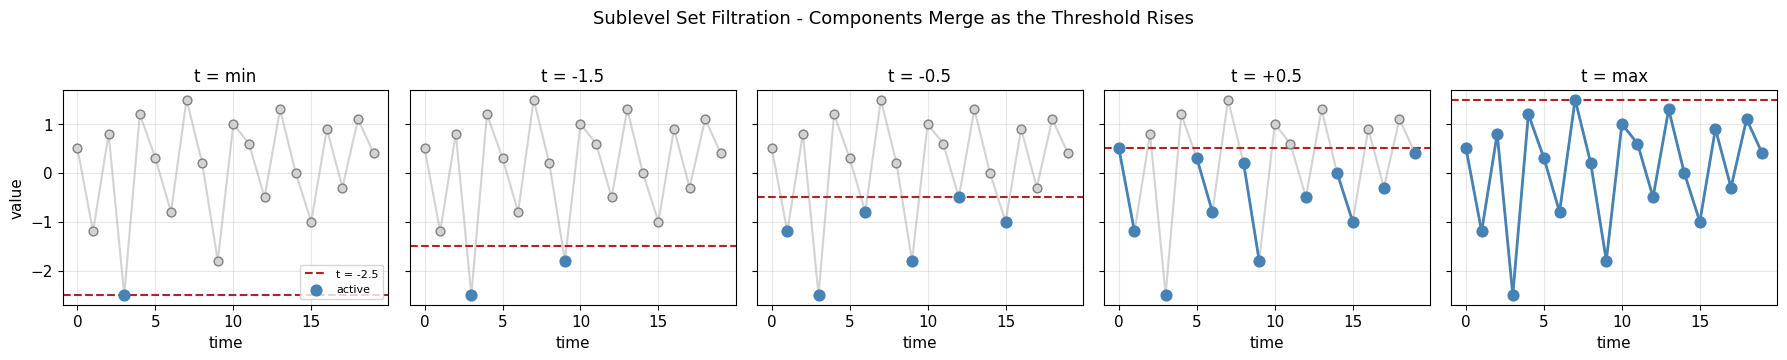

Observation: at t = min only the global minimum is active (1 component).
as t rises, new local minima join, then merge with their neighbours.


In [2]:
# Synthetic signal: several clear local minima
ts_demo = np.array([
    0.5, -1.2,  0.8, -2.5,  1.2,
    0.3, -0.8,  1.5,  0.2, -1.8,
    1.0,  0.6, -0.5,  1.3,  0.0,
    -1.0, 0.9, -0.3,  1.1,  0.4
])
xs = np.arange(len(ts_demo))

thresholds = [-2.5, -1.5, -0.5, 0.5, 1.5]  # 5 thresholds
threshold_labels = ['t = min', 't = -1.5', 't = -0.5', 't = +0.5', 't = max']

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=True)

for ax, t, lbl in zip(axes, thresholds, threshold_labels):
    ax.plot(xs, ts_demo, color='lightgray', lw=1.5, zorder=1)
    ax.axhline(t, color='firebrick', lw=1.5, ls='--', label=f't = {t:.1f}')

    active = ts_demo <= t
    ax.scatter(xs[active], ts_demo[active], s=60, color='steelblue',
               zorder=3, label='active')
    ax.scatter(xs[~active], ts_demo[~active], s=40, color='lightgray',
               edgecolors='gray', zorder=2)

    # Draw neighbour links between active points
    for i in range(len(ts_demo) - 1):
        if active[i] and active[i + 1]:
            ax.plot([xs[i], xs[i+1]], [ts_demo[i], ts_demo[i+1]],
                    color='steelblue', lw=2, zorder=2)

    ax.set_title(lbl)
    ax.set_xlabel('time')

axes[0].set_ylabel('value')
axes[0].legend(fontsize=8)
fig.suptitle('Sublevel Set Filtration - Components Merge as the Threshold Rises',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Observation: at t = min only the global minimum is active (1 component).')
print('as t rises, new local minima join, then merge with their neighbours.')

## 2 - Persistence Diagram & Barcode

### Computing H0 persistence: the Union-Find algorithm

The function below is **standalone** (no project import): a direct copy of
`sublevel_persistence_1d()` from `topology_extraction.py`.

**Algorithm summary:**
1. Sort all neighbour pairs $(i, i+1)$ by edge-value $\max(f(i), f(i+1))$.
2. Merge components with Union-Find as each edge is processed.
3. **Elder rule:** the later-born (higher minimum) component dies; $(b_{young}, f_{edge})$ is a bar.

### What are zero-persistence bars?

In the output below you will see 19 bars, **13 of which have persistence = 0**:
```
0.00 0.00 0.00
0.20 0.20 0.00
0.30 0.30 0.00
...
```

These are **trivial bars born at local maxima**: a component born at a local max
merges immediately at the same edge value -> $b = d$. They are usually omitted
in visualisations (zero-length bars are invisible) and carry no weight in
statistics since their persistence is zero.

In [3]:
# ── Inline copy of sublevel_persistence_1d (no project import) ──────────────

def sublevel_persistence_1d(ts):
    """H0 persistence via sublevel set filtration (union-find, elder rule)."""
    ts = np.asarray(ts, dtype=float)
    n = len(ts)
    if n < 2:
        return np.zeros((0, 2))
    parent   = list(range(n))
    comp_min = ts.tolist()

    def find(x):
        root = x
        while parent[root] != root:
            root = parent[root]
        while parent[x] != root:
            parent[x], x = root, parent[x]
        return root

    edges = sorted((max(ts[i], ts[i+1]), i, i+1) for i in range(n-1))
    pairs = []
    for fval, i, j in edges:
        ri, rj = find(i), find(j)
        if ri == rj:
            continue
        bi, bj = comp_min[ri], comp_min[rj]
        if bi >= bj:                         # ri is younger -> dies
            pairs.append((bi, fval))
            parent[ri] = rj
        else:                                # rj is younger -> dies
            pairs.append((bj, fval))
            parent[rj] = ri
    return np.array(pairs, dtype=float) if pairs else np.zeros((0, 2))


diag_demo = sublevel_persistence_1d(ts_demo)
print(f'Total {len(diag_demo)} bars (global minimum excluded):')
print('  birth    death   persistence')
for b, d in sorted(diag_demo, key=lambda x: -(x[1]-x[0])):
    print(f'  {b:6.2f}   {d:6.2f}   {d-b:.2f}')

Total 19 bars (global minimum excluded):
  birth    death   persistence
   -1.80     1.50   3.30
   -1.00     1.30   2.30
   -1.20     0.80   2.00
   -0.80     1.20   2.00
   -0.50     1.00   1.50
   -0.30     0.90   1.20
    0.40     1.10   0.70
    0.00     0.00   0.00
    0.20     0.20   0.00
    0.30     0.30   0.00
    0.50     0.50   0.00
    0.60     0.60   0.00
    0.80     0.80   0.00
    0.90     0.90   0.00
    1.00     1.00   0.00
    1.10     1.10   0.00
    1.20     1.20   0.00
    1.30     1.30   0.00
    1.50     1.50   0.00


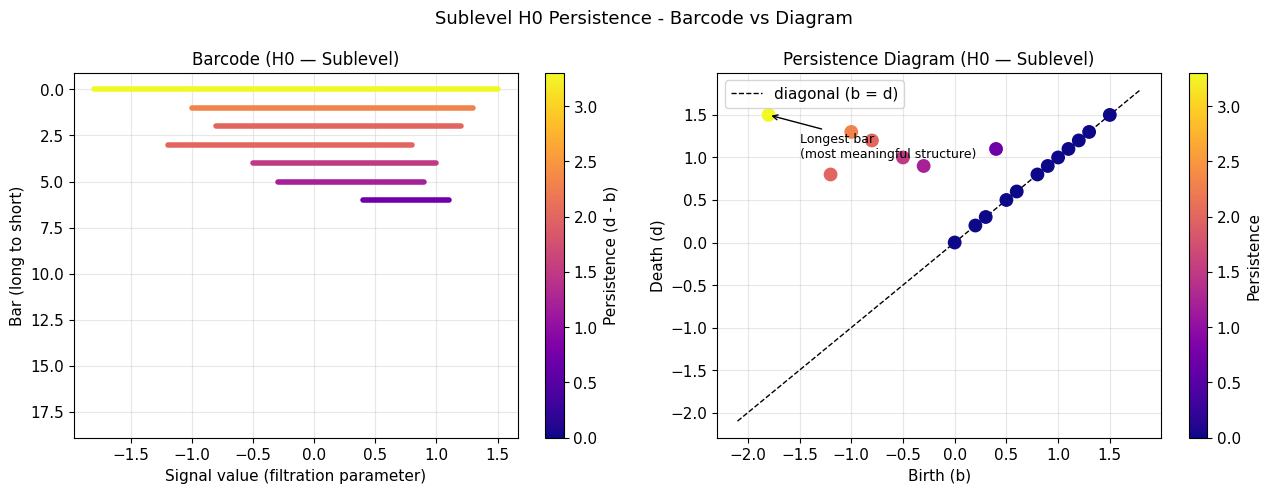

In [4]:
# ── Barcode (left) + Persistence Diagram (right) ────────────────────────────

persistence = diag_demo[:, 1] - diag_demo[:, 0]
sorted_idx  = np.argsort(-persistence)   # long to short

cmap = get_cmap('plasma')
norm = Normalize(vmin=0, vmax=persistence.max())

fig, (ax_bc, ax_pd) = plt.subplots(1, 2, figsize=(13, 5))

# ── Barcode ──────────────────────────────────────────────────────────────────
for rank, idx in enumerate(sorted_idx):
    b, d = diag_demo[idx]
    p = d - b
    color = cmap(norm(p))
    ax_bc.plot([b, d], [rank, rank], lw=4, solid_capstyle='round', color=color)

ax_bc.set_xlabel('Signal value (filtration parameter)')
ax_bc.set_ylabel('Bar (long to short)')
ax_bc.set_title('Barcode (H0 — Sublevel)')
ax_bc.invert_yaxis()
sm = ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax_bc, label='Persistence (d - b)')

# ── Persistence Diagram ───────────────────────────────────────────────────────
b_all, d_all = diag_demo[:, 0], diag_demo[:, 1]
sc = ax_pd.scatter(b_all, d_all, c=persistence, cmap='plasma',
                   norm=norm, s=80, zorder=3)
lim_min = b_all.min() - 0.3
lim_max = d_all.max() + 0.3
ax_pd.plot([lim_min, lim_max], [lim_min, lim_max],
           'k--', lw=1, label='diagonal (b = d)')
ax_pd.set_xlabel('Birth (b)')
ax_pd.set_ylabel('Death (d)')
ax_pd.set_title('Persistence Diagram (H0 — Sublevel)')
ax_pd.legend()
plt.colorbar(sc, ax=ax_pd, label='Persistence')

# Annotation
max_idx = np.argmax(persistence)
ax_pd.annotate('Longest bar\n(most meaningful structure)',
               xy=(b_all[max_idx], d_all[max_idx]),
               xytext=(b_all[max_idx] + 0.3, d_all[max_idx] - 0.5),
               arrowprops=dict(arrowstyle='->', color='k'),
               fontsize=9)

fig.suptitle('Sublevel H0 Persistence - Barcode vs Diagram', fontsize=13)
plt.tight_layout()
plt.show()

## 3 - Spike Detection via Sublevel H0

### Why sub_H0?

Superlevel filtration is said to "catch peaks" — but in practice this requires care:

> **An isolated spike (point anomaly) is typically the global maximum of the signal.**  
> The global maximum is the oldest component of sublevel($-$ts) ("essential class") —  
> **it lives forever and never appears in the finite barcode.**  
> So in the sup_H0 finite barcode the spike disappears; ts_spike ~ ts_flat.

**sub_H0 catches the spike indirectly but reliably:**  
The spike places a **tall barrier** in front of the surrounding valleys.  
The valley component forced to cross that barrier produces a long bar with `death = spike_value`.

| Signal | sub_H0 max persistence | Reason |
|--------|------------------------|----------|
| `ts_spike` | ~ spike_height $-$ noise_min ~ **4.6** | Barrier bar: `death = spike_value` |
| `ts_flat` | ~ noise_range ~ **1.4** | Noise bars only |

In [5]:
# ── Inline superlevel_persistence_1d ─────────────────────────────────────────

def superlevel_persistence_1d(ts):
    """H0 persistence via superlevel set filtration."""
    neg_pairs = sublevel_persistence_1d(-ts)
    if len(neg_pairs) == 0:
        return np.zeros((0, 2))
    return np.column_stack([-neg_pairs[:, 1], -neg_pairs[:, 0]])


# ── Two synthetic signals ────────────────────────────────────────────────────────
rng = np.random.default_rng(42)
noise = rng.normal(0, 0.3, 200)

ts_spike = noise.copy()
ts_spike[100] = 4.0   # isolated spike

ts_flat = noise.copy()   # noise only

# ── What does each filtration see? ──────────────────────────────────────────────
sub_spike = sublevel_persistence_1d(ts_spike)
sub_flat  = sublevel_persistence_1d(ts_flat)
sup_spike = superlevel_persistence_1d(ts_spike)
sup_flat  = superlevel_persistence_1d(ts_flat)

p_sub_sp = sub_spike[:, 1] - sub_spike[:, 0]
p_sub_fl = sub_flat[:,  1] - sub_flat[:,  0]
p_sup_sp = np.abs(sup_spike[:, 1] - sup_spike[:, 0])
p_sup_fl = np.abs(sup_flat[:,  1] - sup_flat[:,  0])

print("sub_H0 max persistence:")
print(f"  ts_spike : {p_sub_sp.max():.3f}  <- spike barrier bar (death = {sub_spike[np.argmax(p_sub_sp), 1]:.1f})")
print(f"  ts_flat  : {p_sub_fl.max():.3f}  ← noise only")
print(f"  Ratio    : {p_sub_sp.max()/p_sub_fl.max():.1f}×")
print()
print("sup_H0 max persistence (spike essential class -> absent from finite bars!):")
print(f"  ts_spike : {p_sup_sp.max():.3f}")
print(f"  ts_flat  : {p_sup_fl.max():.3f}")
print("  -> nearly identical -> sup_H0 cannot distinguish the spike.")


sub_H0 max persistence:
  ts_spike : 4.585  <- spike barrier bar (death = 4.0)
  ts_flat  : 1.459  ← noise only
  Ratio    : 3.1×

sup_H0 max persistence (spike essential class -> absent from finite bars!):
  ts_spike : 1.392
  ts_flat  : 1.278
  -> nearly identical -> sup_H0 cannot distinguish the spike.


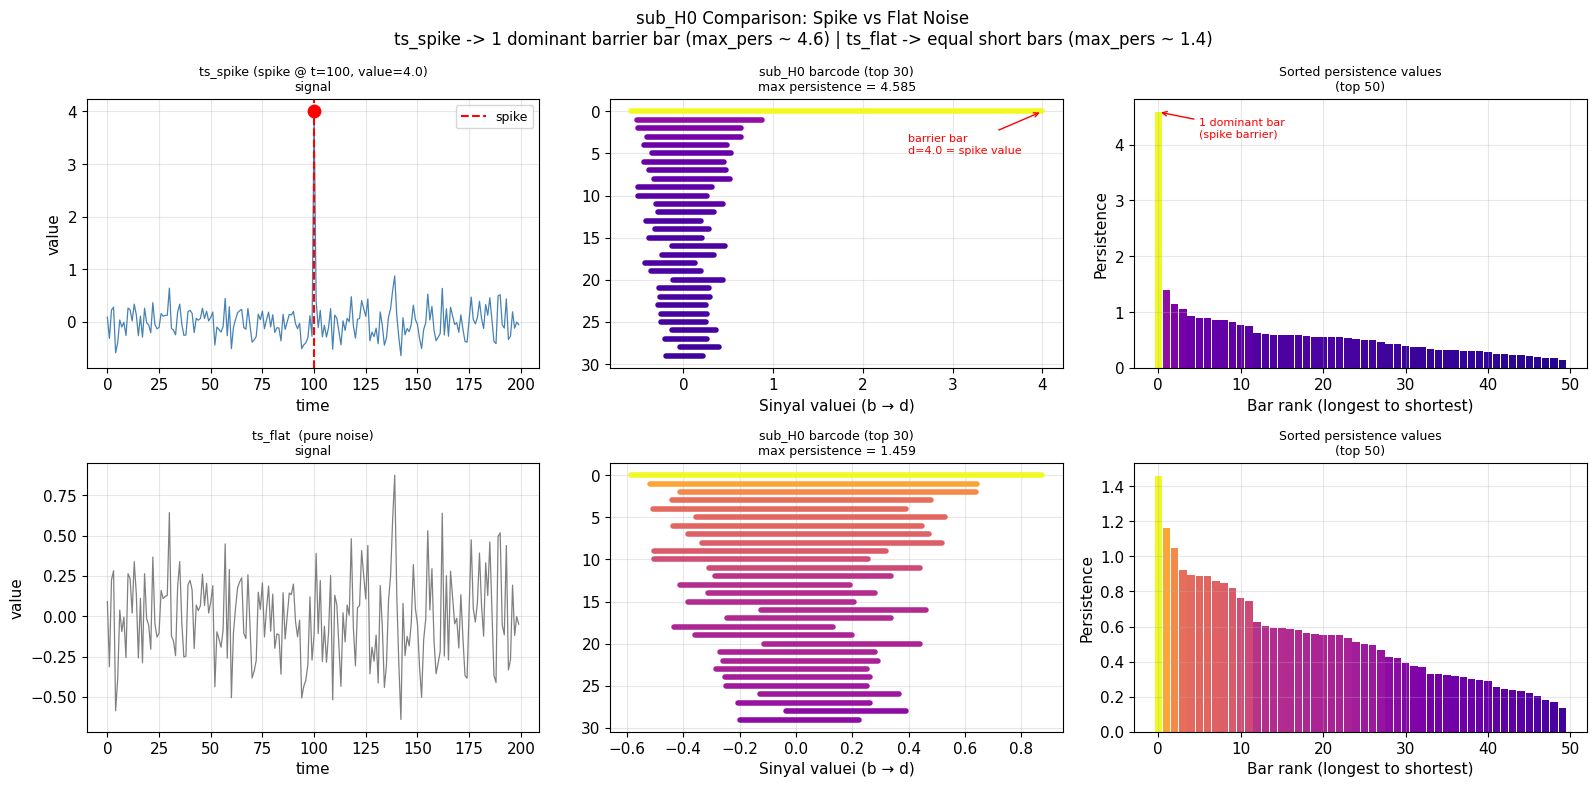

Key observation:
  ts_spike sub_H0: 1 bar with pers=4.59 (others <= 1.39)
  ts_flat  sub_H0: longest bar  pers=1.46

Mechanism: the spike stands like a mountain.
  The valley on the left (e.g. ts[99] ~ -0.3) must wait until
  threshold = spike_value = 4.0 to merge with the right side.
  -> bar: (birth = noise valley, death = 4.0), persistence ~ 4.6


In [6]:
# ── 2x3 plot: signal | sub_H0 barcode | sorted persistence ─────────────────
# sub_H0 shows the spike clearly; sup_H0 does not (essential class issue)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row, (ts, sub, lbl) in enumerate([
    (ts_spike, sub_spike, 'ts_spike (spike @ t=100, value=4.0)'),
    (ts_flat,  sub_flat,  'ts_flat  (pure noise)'),
]):
    pers = sub[:, 1] - sub[:, 0]
    sorted_idx = np.argsort(-pers)
    cmap = get_cmap('plasma')

    # ── Column 0: Signal ──────────────────────────────────────────────────────
    axes[row, 0].plot(ts, lw=0.9, color='steelblue' if row == 0 else 'gray')
    if row == 0:
        axes[row, 0].axvline(100, color='red', lw=1.5, ls='--', label='spike')
        axes[row, 0].scatter([100], [ts[100]], color='red', s=80, zorder=5)
        axes[row, 0].legend(fontsize=9)
    axes[row, 0].set_title(f'{lbl}\nsignal', fontsize=9)
    axes[row, 0].set_xlabel('time')
    axes[row, 0].set_ylabel('value')

    # ── Column 1: sub_H0 barcode (top 30) ─────────────────────────────────
    top_n = min(30, len(pers))
    norm  = Normalize(vmin=0, vmax=pers.max())
    for rank in range(top_n):
        idx = sorted_idx[rank]
        b, d = sub[idx, 0], sub[idx, 1]
        p = d - b
        color = cmap(norm(p))
        axes[row, 1].plot([b, d], [rank, rank], lw=4,
                          solid_capstyle='round', color=color)
        if row == 0 and rank == 0:
            axes[row, 1].annotate(f'barrier bar\nd={d:.1f} = spike value',
                                  xy=(d, rank),
                                  xytext=(d - 1.5, rank + 5),
                                  arrowprops=dict(arrowstyle='->', color='red'),
                                  color='red', fontsize=8)
    axes[row, 1].invert_yaxis()
    axes[row, 1].set_xlabel('Sinyal valuei (b → d)')
    axes[row, 1].set_title(f'sub_H0 barcode (top {top_n})\n'
                           f'max persistence = {pers.max():.3f}', fontsize=9)

    # ── Column 2: Sorted persistence values ─────────────────────────────────
    top_k  = min(50, len(pers))
    sorted_pers = np.sort(pers)[::-1][:top_k]
    bar_colors  = [cmap(norm(p)) for p in sorted_pers]
    axes[row, 2].bar(range(top_k), sorted_pers, color=bar_colors,
                     edgecolor='none', width=0.9)
    axes[row, 2].set_xlabel('Bar rank (longest to shortest)')
    axes[row, 2].set_ylabel('Persistence')
    axes[row, 2].set_title(f'Sorted persistence values\n'
                           f'(top {top_k})', fontsize=9)
    if row == 0:
        axes[row, 2].annotate('1 dominant bar\n(spike barrier)',
                              xy=(0, sorted_pers[0]),
                              xytext=(5, sorted_pers[0] * 0.9),
                              arrowprops=dict(arrowstyle='->', color='red'),
                              color='red', fontsize=8)

fig.suptitle('sub_H0 Comparison: Spike vs Flat Noise\n'
             'ts_spike -> 1 dominant barrier bar (max_pers ~ 4.6) | '
             'ts_flat -> equal short bars (max_pers ~ 1.4)',
             fontsize=12)
plt.tight_layout()
plt.show()

print("Key observation:")
print(f"  ts_spike sub_H0: 1 bar with pers={p_sub_sp.max():.2f} (others <= {np.sort(p_sub_sp)[-2]:.2f})")
print(f"  ts_flat  sub_H0: longest bar  pers={p_sub_fl.max():.2f}")
print()
print("Mechanism: the spike stands like a mountain.")
print("  The valley on the left (e.g. ts[99] ~ -0.3) must wait until")
print("  threshold = spike_value = 4.0 to merge with the right side.")
print("  -> bar: (birth = noise valley, death = 4.0), persistence ~ 4.6")


## 4 - Takens Embedding & H1 (Cyclic Structure & Robustness)

### Core idea

sub_H0 / sup_H0 cannot directly capture cyclic/periodic structure.
For that, we use the **Takens embedding**:

$$\phi(s) = \bigl(f(s),\, f(s+\tau),\, \ldots,\, f(s+(d-1)\tau)\bigr)$$

For a periodic signal this embedding forms a **circle**.  
Under Vietoris-Rips filtration, **H1** (1-dim homology) captures this circle as one long bar.

### Choosing tau matters

| tau | Geometry | H1 |
|-----|----------|----|
| `tau=1` (too small) | Thin ellipse ~ line | persistence ~ 0 |
| `tau ~ quarter period` | **Unit circle** | persistence maximum |
| `tau ~ half period` | Thin again | persistence drops |

-> aim for `tau * dt ~ pi/2`: `(sin t, sin(t+pi/2)) = (sin t, cos t)` -> perfect circle.

### Robustness: resistance to noise

The headline advantage of TDA is the **stability theorem** (Cohen-Steiner 2007):
> After perturbing the signal by epsilon, the persistence diagram changes by at most epsilon.
> Short bars (<= epsilon) are noise; long bars (>> epsilon) are real structure.

**Observation in the demo below**: at sigma=0.2 the absolute value of the dominant
H1 bar **drops to 44 %** (1.68 -> 0.74), but the **dominance ratio** (1st bar / 2nd bar)
stays around ~6x — i.e. "noise bars << real bar" remains clearly separable for an
ML model. Message: TDA is **moderately robust in absolute magnitude** but **highly robust
in relative terms**.

In [7]:
# ── Takens embedding (tau = quarter period, d=2) ─────────────────────────────
#
# Goal: demonstrate the robustness of TDA against noise.
#   * Clean sine        -> perfect circle -> strong H1
#   * Noisy sine (sigma=0.2) -> slightly distorted circle -> H1 still strong
#
# tau = quarter period -> (sin t, sin(t+pi/2)) = (sin t, cos t) -> unit circle
#   600 points, 3 periods -> 1 period = 200 steps -> tau = 50

t_arr = np.linspace(0, 6 * np.pi, 600)
tau   = 50   # quarter period

rng   = np.random.default_rng(0)
sigma = 0.2                                # noise std (sine amplitude = 1 -> SNR=5)

ts_clean = np.sin(t_arr)
ts_noisy = np.sin(t_arr) + sigma * rng.standard_normal(600)

cloud_clean = np.column_stack([ts_clean[:-tau], ts_clean[tau:]])
cloud_noisy = np.column_stack([ts_noisy[:-tau], ts_noisy[tau:]])

print(f'tau = {tau}  |  σ = {sigma}  |  SNR ≈ {1/sigma:.1f}')
print(f'cloud shape: {cloud_clean.shape}')

# ── Ripser H1 ─────────────────────────────────────────────────────────────────
n_perm_cloud = min(200, len(cloud_clean) - 1)
res_clean = ripser(cloud_clean, maxdim=1, n_perm=n_perm_cloud)
res_noisy = ripser(cloud_noisy, maxdim=1, n_perm=n_perm_cloud)

dgm_h1_clean = res_clean['dgms'][1]
dgm_h1_noisy = res_noisy['dgms'][1]

def finite_pers(dgm):
    finite = dgm[np.isfinite(dgm[:, 1])]
    if len(finite) == 0:
        return []
    return sorted(finite[:, 1] - finite[:, 0], reverse=True)

fp_clean = finite_pers(dgm_h1_clean)
fp_noisy = finite_pers(dgm_h1_noisy)

print()
print('Clean sine     H1 persistence (top 3):', [f'{p:.3f}' for p in fp_clean[:3]])
print('Noisy sine     H1 persistence (top 3):', [f'{p:.3f}' for p in fp_noisy[:3]])
if fp_clean and fp_noisy:
    ratio = fp_noisy[0] / fp_clean[0]
    print(f'  -> at sigma={sigma} the H1 signal is preserved at {ratio*100:.0f}%  '
          f'(noise bars << dominant bar)')

tau = 50  |  σ = 0.2  |  SNR ≈ 5.0
cloud shape: (550, 2)

Clean sine     H1 persistence (top 3): ['1.680']
Noisy sine     H1 persistence (top 3): ['0.742', '0.118', '0.101']
  -> at sigma=0.2 the H1 signal is preserved at 44%  (noise bars << dominant bar)


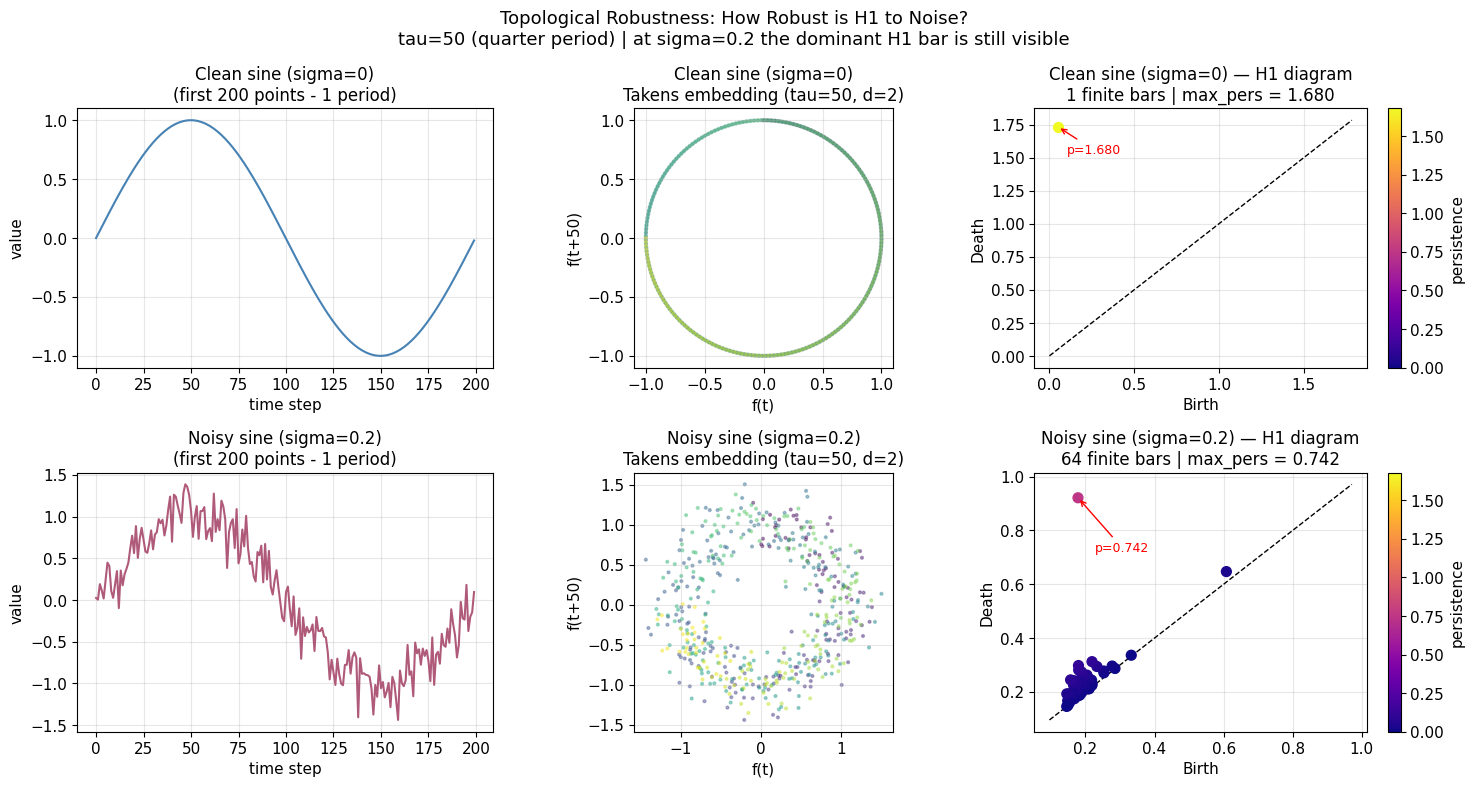

Clean H1:     max_pers = 1.680
Noisy H1:     max_pers = 0.742  (sigma=0.2 -> 44% preserved)
Second longest bar (noisy):    0.118  (16% of dominant -> clear gap)


In [8]:
# ── 3x2 plot: signal | embedding | H1 diagram ────────────────────────────────

def plot_h1_diagram(ax, dgm, title, max_pers_ref=None):
    finite = dgm[np.isfinite(dgm[:, 1])]
    if len(finite) == 0:
        ax.set_title(title + '\n(no H1 bar)')
        return
    pers = finite[:, 1] - finite[:, 0]
    sc = ax.scatter(finite[:, 0], finite[:, 1],
                    c=pers, cmap='plasma', s=50,
                    vmin=0, vmax=(max_pers_ref or pers.max()),
                    zorder=3)
    lo = finite.min() - 0.05
    hi = finite.max() + 0.05
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    plt.colorbar(sc, ax=ax, label='persistence')
    # Annotate the dominant bar
    top_idx = np.argmax(pers)
    ax.annotate(f'p={pers[top_idx]:.3f}',
                xy=(finite[top_idx, 0], finite[top_idx, 1]),
                xytext=(finite[top_idx, 0] + 0.05, finite[top_idx, 1] - 0.2),
                arrowprops=dict(arrowstyle='->', color='red'),
                color='red', fontsize=9)
    ax.set_xlabel('Birth'); ax.set_ylabel('Death')
    ax.set_title(title)


# Shared colour scale
all_pers = []
for dgm in [dgm_h1_clean, dgm_h1_noisy]:
    finite = dgm[np.isfinite(dgm[:, 1])]
    if len(finite):
        all_pers.extend((finite[:, 1] - finite[:, 0]).tolist())
max_pers_ref = max(all_pers) if all_pers else 1.0

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, (ts, cloud, dgm, lbl, fp) in enumerate([
    (ts_clean, cloud_clean, dgm_h1_clean, f'Clean sine (sigma=0)',     fp_clean),
    (ts_noisy, cloud_noisy, dgm_h1_noisy, f'Noisy sine (sigma={sigma})', fp_noisy),
]):
    color = 'steelblue' if row == 0 else '#b05a7a'

    # ── Column 0: Signal (1 periyot = 200 nokta) ─────────────────────────────
    axes[row, 0].plot(ts[:200], lw=1.5, color=color)
    axes[row, 0].set_title(f'{lbl}\n(first 200 points - 1 period)')
    axes[row, 0].set_xlabel('time step'); axes[row, 0].set_ylabel('value')

    # ── Column 1: 2D embedding ────────────────────────────────────────────────
    axes[row, 1].scatter(cloud[:, 0], cloud[:, 1],
                         s=4, alpha=0.4,
                         c=np.arange(len(cloud)), cmap='viridis')
    axes[row, 1].set_title(f'{lbl}\nTakens embedding (tau={tau}, d=2)')
    axes[row, 1].set_xlabel('f(t)'); axes[row, 1].set_ylabel(f'f(t+{tau})')
    axes[row, 1].set_aspect('equal')

    # ── Column 2: H1 diagram ──────────────────────────────────────────────────
    n_bars = len(fp)
    title_str = (f'{lbl} — H1 diagram\n'
                 f'{n_bars} finite bars | max_pers = {fp[0]:.3f}' if fp
                 else f'{lbl} — H1 diagram\n(no finite bars)')
    plot_h1_diagram(axes[row, 2], dgm, title_str, max_pers_ref)

fig.suptitle(
    f'Topological Robustness: How Robust is H1 to Noise?\n'
    f'tau={tau} (quarter period) | at sigma={sigma} the dominant H1 bar is still visible',
    fontsize=13)
plt.tight_layout()
plt.show()

if fp_clean and fp_noisy:
    ratio = fp_noisy[0] / fp_clean[0]
    print(f'Clean H1:     max_pers = {fp_clean[0]:.3f}')
    print(f'Noisy H1:     max_pers = {fp_noisy[0]:.3f}  (sigma={sigma} -> {ratio*100:.0f}% preserved)')
    if len(fp_noisy) > 1:
        print(f'Second longest bar (noisy):    {fp_noisy[1]:.3f}  '
              f'({fp_noisy[1]/fp_noisy[0]*100:.0f}% of dominant -> clear gap)')

## 5 - From a Diagram to 8 Numbers: Vectorisation

We extract 8 scalar features from each persistence diagram for ML pipelines:

| # | Name | Formula | Meaning |
|---|------|---------|---------|
| 1 | `carl_f1` | $\sum b_i p_i$ | Birth-weighted total (**signed** - birth can be negative) |
| 2 | `carl_f2` | $\sum (d_{\max}-d_i) p_i$ | Distance-to-death weighted total |
| 3 | `carl_f3` | $\sum b_i^2 p_i^4$ | Higher-degree birth energy (always >= 0) |
| 4 | `carl_f4` | $\sum (d_{\max}-d_i)^2 p_i^4$ | Higher-degree death energy |
| 5 | `carl_f5_max` | $\max p_i$ | Longest bar |
| 6 | `entropy` | $-\sum \hat{p}_i \log \hat{p}_i$ | Distribution of bar lengths |
| 7 | `landscape_l1` | $\|\lambda_1\|_1$ | L1 norm of mean landscape |
| 8 | `landscape_l2` | $\|\lambda_1\|_2$ | L2 norm of mean landscape |

$p_i = d_i - b_i$ (persistence = bar length, **always > 0**)

> **Note - negative Carlsson values:**
> `carl_f1` and `carl_f2` can be **signed**, because `b` and `d_max - d` can be negative
> (when signal values go below 0). For `ts_demo` below you will see `carl_f1 = -13.07` -
> this is not a bug; the signal is mostly in the negative region.

In [9]:
# ── Inline functions (no project import) ───────────────────────────────────

def carlsson_coordinates(diag):
    """5 Carlsson coordinates."""
    diag = diag[np.isfinite(diag).all(axis=1)]
    diag = diag[diag[:, 1] > diag[:, 0]]
    if len(diag) == 0:
        return np.zeros(5)
    b, d  = diag[:, 0], diag[:, 1]
    p     = d - b
    d_max = float(d.max())
    return np.array([
        np.sum(b * p),
        np.sum((d_max - d) * p),
        np.sum(b**2 * p**4),
        np.sum((d_max - d)**2 * p**4),
        float(p.max()),
    ])


def persistent_entropy(diag):
    """Shannon entropy of normalised bar lengths."""
    diag = diag[np.isfinite(diag).all(axis=1)]
    diag = diag[diag[:, 1] > diag[:, 0]]
    if len(diag) == 0:
        return 0.0
    p = diag[:, 1] - diag[:, 0]
    L = p.sum()
    probs = p / L
    return float(-np.sum(probs * np.log(probs + 1e-12)))


def landscape_norms(diag, n_landscapes=5, resolution=100):
    """Persistence landscape L1 and L2 norms."""
    diag = diag[np.isfinite(diag).all(axis=1)]
    diag = diag[diag[:, 1] > diag[:, 0]]
    if len(diag) == 0:
        return 0.0, 0.0, np.zeros(resolution), np.linspace(0, 1, resolution)
    min_b, max_d = diag[:, 0].min(), diag[:, 1].max()
    grid = np.linspace(min_b, max_d, resolution)
    lands = np.zeros((n_landscapes, resolution))
    b, d  = diag[:, 0], diag[:, 1]
    for i, x in enumerate(grid):
        active = (b <= x) & (x <= d)
        if active.any():
            vals = np.sort(np.minimum(x - b[active], d[active] - x))[::-1]
            k = min(n_landscapes, len(vals))
            lands[:k, i] = vals[:k]
    lvec = lands.mean(axis=0)
    return float(np.sum(np.abs(lvec))), float(np.sqrt(np.sum(lvec**2))), lvec, grid


# ── Demo diagram: H0 sublevel -> ts_demo ──────────────────────────────────────
demo_diag = sublevel_persistence_1d(ts_demo)

cc  = carlsson_coordinates(demo_diag)
ent = persistent_entropy(demo_diag)
l1, l2, lvec, lgrid = landscape_norms(demo_diag)

print('ts_demo sublevel H0 - 8 features:')
print(f'  carl_f1      = {cc[0]:8.4f}   # birth-weighted total persistence')
print(f'  carl_f2      = {cc[1]:8.4f}   # distance from max_death')
print(f'  carl_f3      = {cc[2]:8.4f}   # higher-degree birth energy')
print(f'  carl_f4      = {cc[3]:8.4f}   # higher-degree death energy')
print(f'  carl_f5_max  = {cc[4]:8.4f}   # longest bar')
print(f'  entropy      = {ent:8.4f}   # disorder of bar distribution')
print(f'  landscape_l1 = {l1:8.4f}   # landscape L1 norm')
print(f'  landscape_l2 = {l2:8.4f}   # landscape L2 norm')

ts_demo sublevel H0 - 8 features:
  carl_f1      = -13.0700   # birth-weighted total persistence
  carl_f2      =   4.2100   # distance from max_death
  carl_f3      = 446.9932   # higher-degree birth energy
  carl_f4      =  12.4499   # higher-degree death energy
  carl_f5_max  =   3.3000   # longest bar
  entropy      =   1.8568   # disorder of bar distribution
  landscape_l1 =  40.3467   # landscape L1 norm
  landscape_l2 =   5.1769   # landscape L2 norm


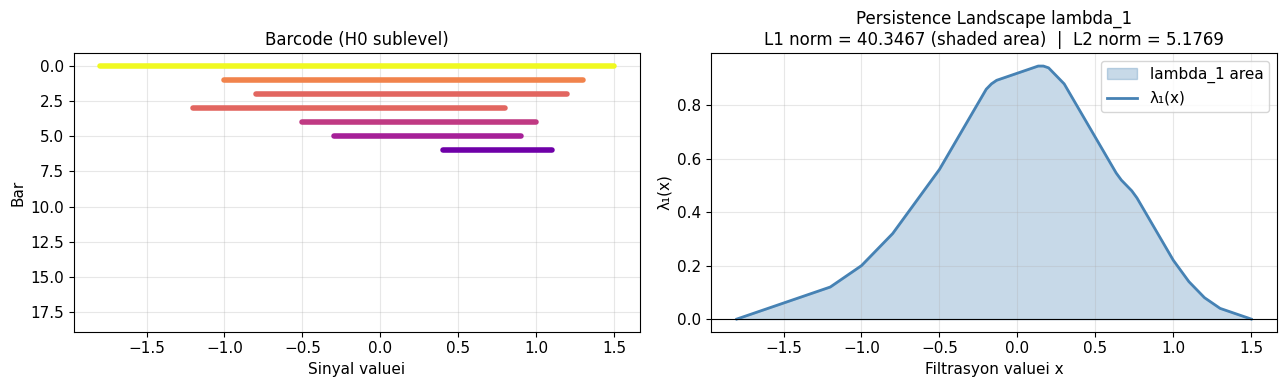

Landscape λ₁(x): her x'te en uzun tent fonksiyonunun valuei.
L1 norm = area under lambda_1 - magnitude of the dominant topological feature.


In [10]:
# ── Persistence Landscape lambda_1 plot ──────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: barcode (again - for reference)
persistence_demo = demo_diag[:, 1] - demo_diag[:, 0]
sorted_idx = np.argsort(-persistence_demo)
cmap = get_cmap('plasma')
norm = Normalize(vmin=0, vmax=persistence_demo.max())
for rank, idx in enumerate(sorted_idx):
    b, d = demo_diag[idx]
    axes[0].plot([b, d], [rank, rank], lw=4,
                 solid_capstyle='round', color=cmap(norm(d - b)))
axes[0].set_xlabel('Sinyal valuei'); axes[0].set_ylabel('Bar')
axes[0].set_title('Barcode (H0 sublevel)')
axes[0].invert_yaxis()

# right: persistence landscape
axes[1].fill_between(lgrid, 0, lvec, alpha=0.3, color='steelblue', label='lambda_1 area')
axes[1].plot(lgrid, lvec, lw=2, color='steelblue', label='λ₁(x)')
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_xlabel('Filtrasyon valuei x')
axes[1].set_ylabel('λ₁(x)')
axes[1].set_title(f'Persistence Landscape lambda_1\n'
                  f'L1 norm = {l1:.4f} (shaded area)  |  L2 norm = {l2:.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Landscape λ₁(x): her x\'te en uzun tent fonksiyonunun valuei.')
print('L1 norm = area under lambda_1 - magnitude of the dominant topological feature.')

---
# PART 2 - Project Pipeline (`topology_extraction.py`)

> **From here on we use project files.**  
> Run the notebook from `reports/tda-background/`,  
> or update the `ROOT` variable below to your actual repo path.

## 6 - Project Setup & Data Loading

We import the real project code: `02-preprocessing/topology_extraction.py`

In [11]:
import sys
from pathlib import Path
import pandas as pd

ROOT = Path('../../')   # reports/tda-background/ -> repo root
sys.path.insert(0, str(ROOT / '02-preprocessing'))

from topology_extraction import (
    sublevel_persistence_1d  as _sub,
    superlevel_persistence_1d as _sup,
    carlsson_coordinates, persistent_entropy, diagram_to_stats,
    SublevelFeatureExtractor, TopologicalFeatureExtractor,
    CombinedExtractor, estimate_delay_mi, _STAT_SUFFIXES
)

print('topology_extraction.py imported successfully.')
print(f'_STAT_SUFFIXES: {_STAT_SUFFIXES}')

topology_extraction.py imported successfully.
_STAT_SUFFIXES: ['carl_f1', 'carl_f2', 'carl_f3', 'carl_f4', 'carl_f5_max', 'entropy', 'landscape_l1', 'landscape_l2']


In [12]:
# ── Load raw data ────────────────────────────────────────────────────────────

raw_path = ROOT / 'data/raw/topo-test/topo-test.parquet'
df_raw = pd.read_parquet(raw_path,
                         columns=['series_id', 'time', 'data', 'primary_category'])

print(f'Raw data: {len(df_raw):,} rows')
print(f'Number of series: {df_raw["series_id"].nunique()}')
print(f'Number of classes: {df_raw["primary_category"].nunique()}')
print()
print('Class distribution:')
print(df_raw.groupby("primary_category")["series_id"].nunique().to_string())

Raw data: 1,000,000 rows
Number of series: 1000
Number of classes: 10

Class distribution:
primary_category
collective_anomaly     100
contextual_anomaly     100
deterministic_trend    100
mean_shift             100
point_anomaly          100
stationary             100
stochastic_trend       100
trend_shift            100
variance_shift         100
volatility             100


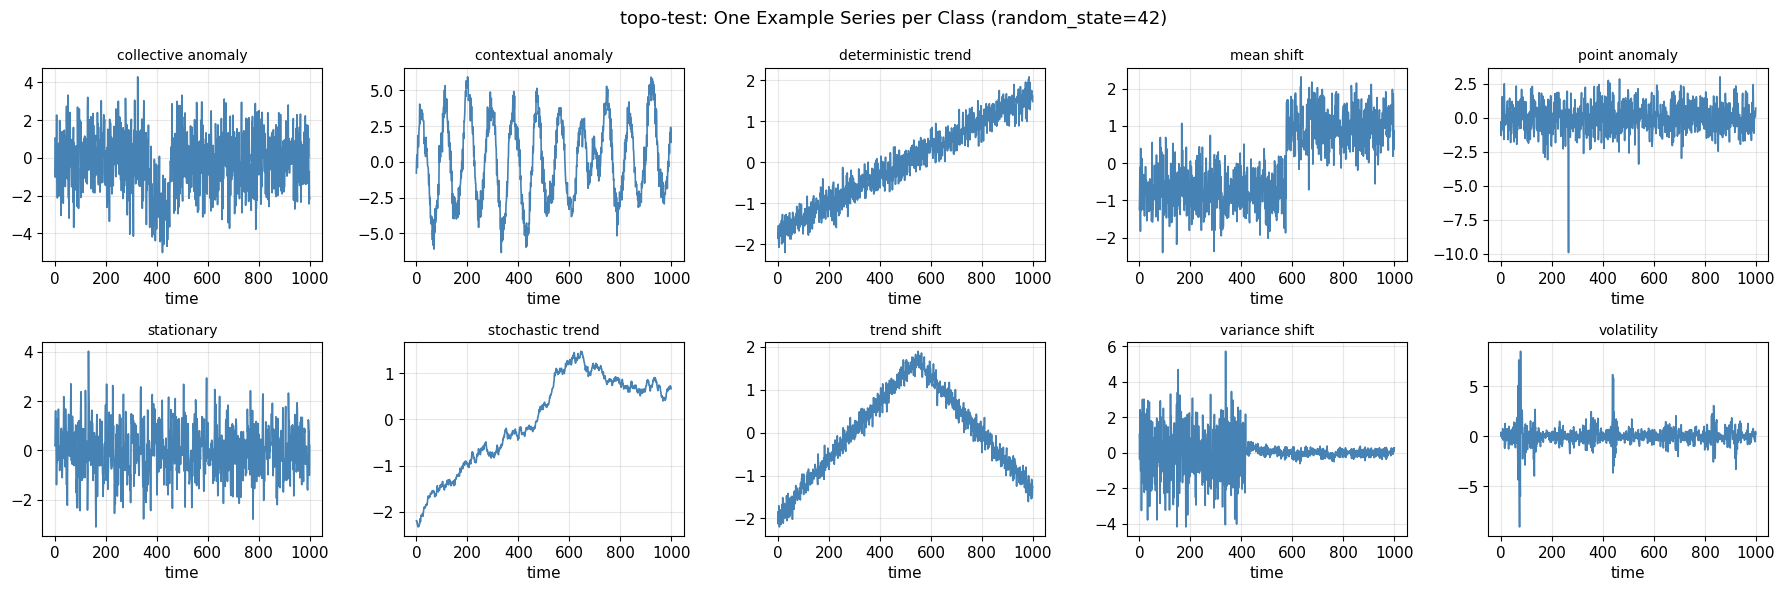

In [13]:
# ── Pick 1 example per class - 2x5 grid plot ───────────────────────────────

CLASSES = sorted(df_raw['primary_category'].unique())
rng_ex  = np.random.default_rng(42)

example_series = {}
for cls in CLASSES:
    ids = df_raw[df_raw['primary_category'] == cls]['series_id'].unique()
    chosen_id = rng_ex.choice(ids)
    vals = (df_raw[df_raw['series_id'] == chosen_id]
            .sort_values('time')['data'].values)
    example_series[cls] = vals

fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharey=False)
for ax, cls in zip(axes.flat, CLASSES):
    ax.plot(example_series[cls], lw=1.2, color='steelblue')
    ax.set_title(cls.replace('_', ' '), fontsize=10)
    ax.set_xlabel('time')

fig.suptitle('topo-test: One Example Series per Class (random_state=42)', fontsize=13)
plt.tight_layout()
plt.show()

## 7 - sub_H0 & sup_H0 on Real Series

Let us verify the concepts from Sections 1-3 on real classes.
We pick 4 characteristic classes:

| Class | Expected sub_H0 | Expected sup_H0 |
|-------|-----------------|------------------|
| `stationary` | short equal bars | short equal bars |
| `mean_shift` | **1-2 long bars** (level-shift barrier) | medium bars |
| `point_anomaly` | **1 very long bar** (spike barrier mechanism) | spike essential class (absent from finite barcode) |
| `trend_shift` | **1 dominant long bar** (trend break) | spread medium bars |

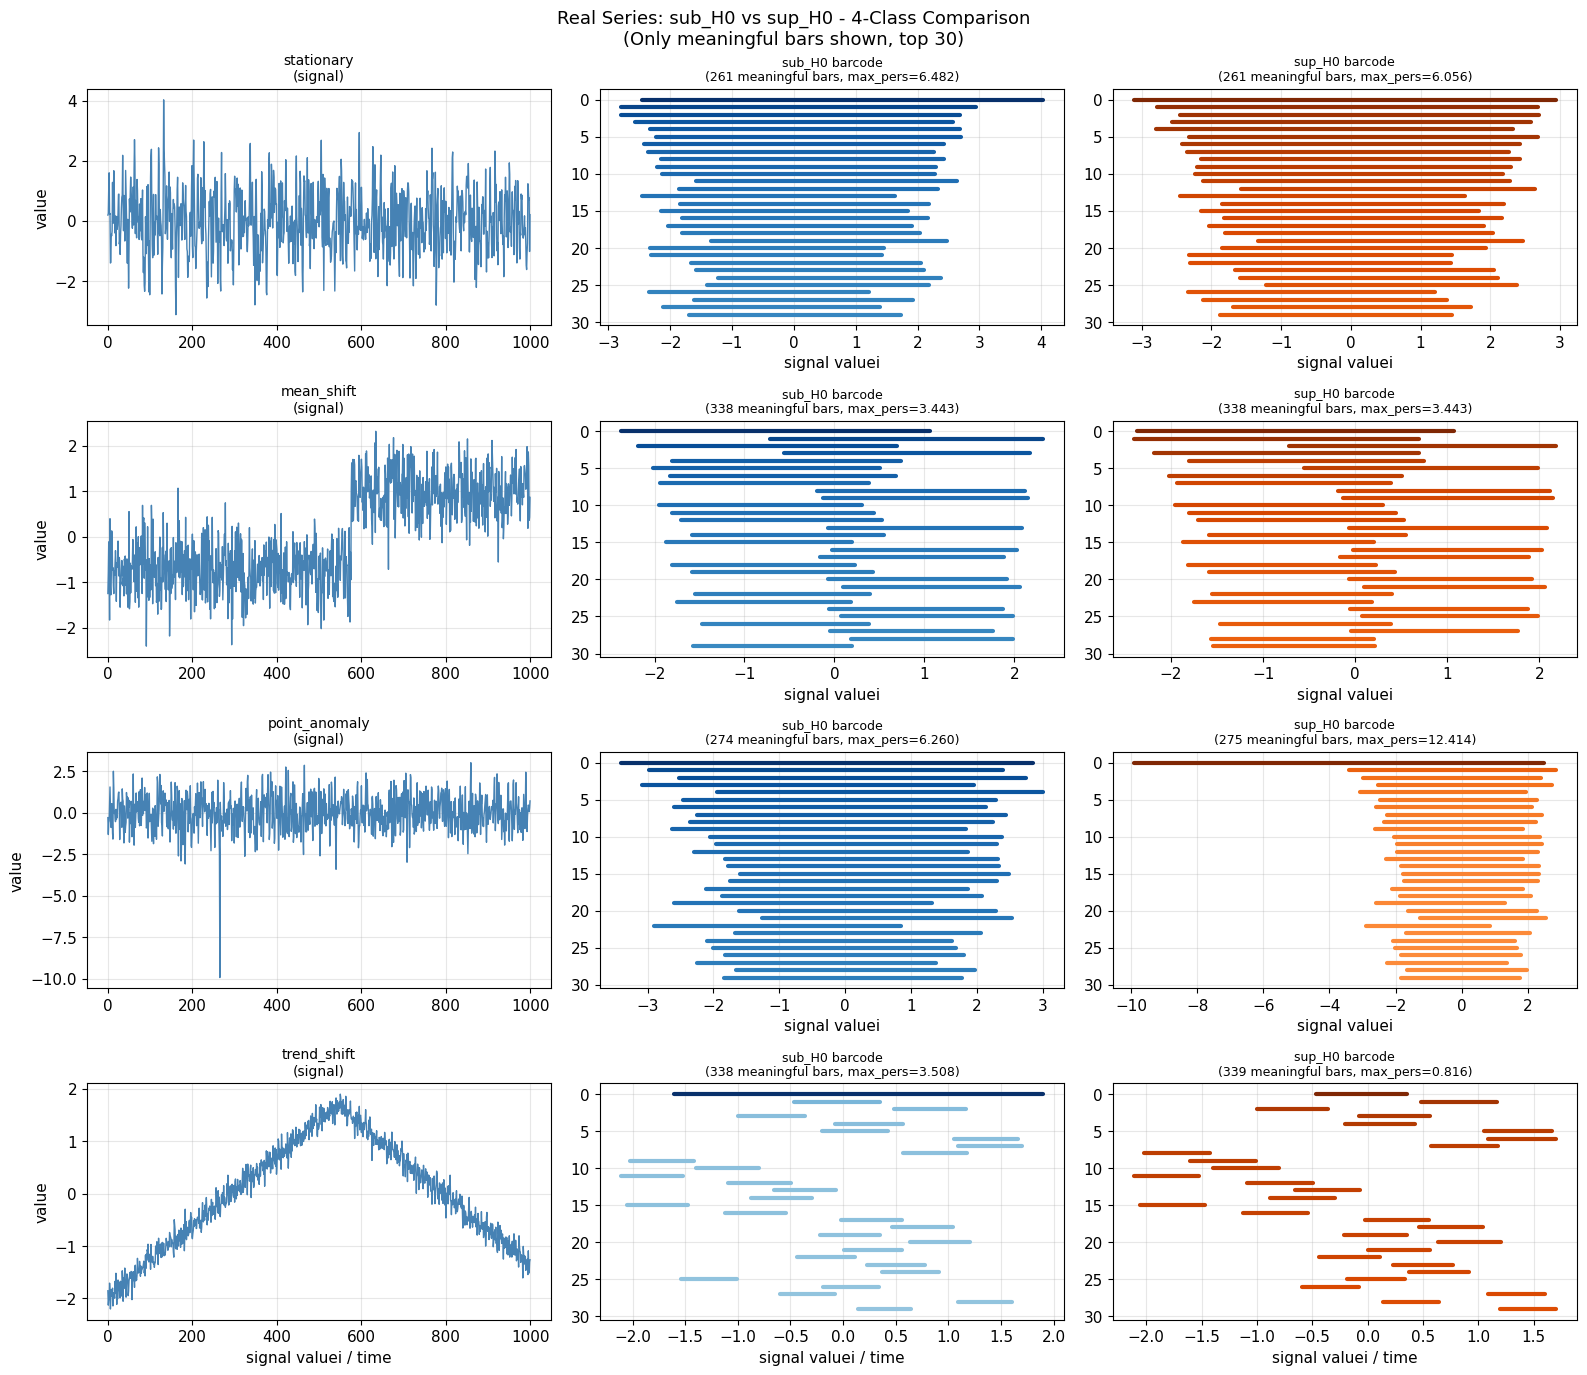

Expected patterns:
  stationary   - short, equal bars (uniform noise both directions)
  mean_shift   - 1-2 long sub_H0 bars (level-shift barrier)
  point_anomaly- 1 dominant sub_H0 bar (spike -> tall barrier)
  trend_shift  - 1 dominant sub_H0 bar (trend break)


In [14]:
DEMO_CLASSES = ['stationary', 'mean_shift', 'point_anomaly', 'trend_shift']

fig, axes = plt.subplots(4, 3, figsize=(16, 14))

for row, cls in enumerate(DEMO_CLASSES):
    ts = example_series[cls].astype(float)

    # ── Column 0: Signal ──────────────────────────────────────────────────────
    axes[row, 0].plot(ts, lw=1.0, color='steelblue')
    axes[row, 0].set_title(f'{cls}\n(signal)', fontsize=10)
    axes[row, 0].set_ylabel('value')

    # ── Column 1: sub_H0 barcode ──────────────────────────────────────────────
    sub_diag = _sub(ts)
    if len(sub_diag):
        pers_s = sub_diag[:, 1] - sub_diag[:, 0]
        # Show only non-zero persistence bars (top 30)
        pos_mask = pers_s > 1e-6
        sub_pos  = sub_diag[pos_mask]
        pers_pos = pers_s[pos_mask]
        top_n    = min(30, len(pers_pos))
        idx_top  = np.argsort(-pers_pos)[:top_n]

        cmap_s = get_cmap('Blues')
        nrm_s  = Normalize(vmin=0, vmax=pers_pos.max())
        for rank, i in enumerate(idx_top):
            axes[row, 1].plot([sub_pos[i, 0], sub_pos[i, 1]],
                              [rank, rank], lw=3,
                              solid_capstyle='round',
                              color=cmap_s(0.3 + 0.7 * nrm_s(pers_pos[i])))
        max_pers = pers_pos.max()
        n_pos    = pos_mask.sum()
    else:
        max_pers, n_pos = 0.0, 0

    axes[row, 1].set_title(
        f'sub_H0 barcode\n({n_pos} meaningful bars, max_pers={max_pers:.3f})',
        fontsize=9)
    axes[row, 1].invert_yaxis()
    axes[row, 1].set_xlabel('signal valuei')

    # ── Column 2: sup_H0 barcode ──────────────────────────────────────────────
    sup_diag = _sup(ts)
    if len(sup_diag):
        b_sup   = np.minimum(sup_diag[:, 0], sup_diag[:, 1])
        d_sup   = np.maximum(sup_diag[:, 0], sup_diag[:, 1])
        pers_sp = d_sup - b_sup
        pos_sp  = pers_sp > 1e-6
        b_pos, d_pos, p_pos = b_sup[pos_sp], d_sup[pos_sp], pers_sp[pos_sp]
        top_sp  = min(30, len(p_pos))
        idx_sp  = np.argsort(-p_pos)[:top_sp]

        cmap_sp = get_cmap('Oranges')
        nrm_sp  = Normalize(vmin=0, vmax=p_pos.max())
        for rank, i in enumerate(idx_sp):
            axes[row, 2].plot([b_pos[i], d_pos[i]], [rank, rank], lw=3,
                              solid_capstyle='round',
                              color=cmap_sp(0.3 + 0.7 * nrm_sp(p_pos[i])))
        max_sp = p_pos.max()
        n_sp   = pos_sp.sum()
    else:
        max_sp, n_sp = 0.0, 0

    axes[row, 2].set_title(
        f'sup_H0 barcode\n({n_sp} meaningful bars, max_pers={max_sp:.3f})',
        fontsize=9)
    axes[row, 2].invert_yaxis()
    axes[row, 2].set_xlabel('signal valuei')

for ax in axes[-1]:
    ax.set_xlabel('signal valuei / time')

fig.suptitle('Real Series: sub_H0 vs sup_H0 - 4-Class Comparison\n'
             '(Only meaningful bars shown, top 30)',
             fontsize=13)
plt.tight_layout()
plt.show()

print('Expected patterns:')
print('  stationary   - short, equal bars (uniform noise both directions)')
print('  mean_shift   - 1-2 long sub_H0 bars (level-shift barrier)')
print('  point_anomaly- 1 dominant sub_H0 bar (spike -> tall barrier)')
print('  trend_shift  - 1 dominant sub_H0 bar (trend break)')

## 8 - Production Extractor: the `sublevel+h1` Method

**`CombinedExtractor`** combines two extractors:

```
CombinedExtractor
+- TopologicalFeatureExtractor(homology_dims=(1,))  -> H1 x 8 = 8 features
|       Takens embedding -> Vietoris-Rips -> Ripser
+- SublevelFeatureExtractor()                        -> (sub_H0 + sup_H0) x 8 = 16 features
        Union-Find -> barcode -> diagram_to_stats()
                                                      TOTAL: 24 features
```

Feature naming convention: `topo__{diagram}__{feature}`  
Example: `topo__sub_H0__carl_f3`

In [15]:
# ── Build CombinedExtractor ─────────────────────────────────────────────────

extractor = CombinedExtractor(
    TopologicalFeatureExtractor(homology_dims=(1,), n_perm=500),
    SublevelFeatureExtractor()
)

print(f'Total number of features : {extractor.n_features()}')
print(f'Feature names (first 5): {extractor.get_feature_names()[:5]}')
print(f'Feature names (last 5): {extractor.get_feature_names()[-5:]}')

# ── Run on one trend_shift series ──────────────────────────────────
ts_trend = example_series['trend_shift'].astype(float)
feat_vec, delay, dim = extractor.extract_one(ts_trend)

print(f'\nExtracted feature vector: shape={feat_vec.shape}')
print(f'Takens delay: τ={delay}, dimension: d={dim}')

Total number of features : 24
Feature names (first 5): ['topo__H1__carl_f1', 'topo__H1__carl_f2', 'topo__H1__carl_f3', 'topo__H1__carl_f4', 'topo__H1__carl_f5_max']
Feature names (last 5): ['topo__sup_H0__carl_f4', 'topo__sup_H0__carl_f5_max', 'topo__sup_H0__entropy', 'topo__sup_H0__landscape_l1', 'topo__sup_H0__landscape_l2']

Extracted feature vector: shape=(24,)
Takens delay: τ=1, dimension: d=3


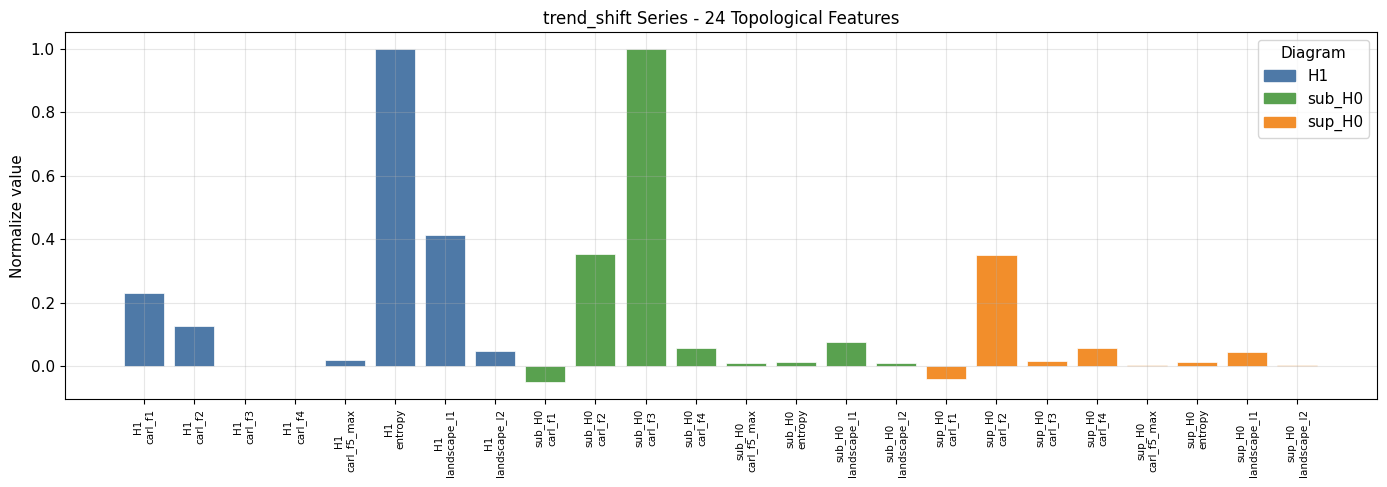


Feature table:
Feature name                                  Value
----------------------------------------------------
topo__H1__carl_f1                           0.23016
topo__H1__carl_f2                           0.12599
topo__H1__carl_f3                           0.00001
topo__H1__carl_f4                           0.00000
topo__H1__carl_f5_max                       0.01952
topo__H1__entropy                           1.00000
topo__H1__landscape_l1                      0.41241
topo__H1__landscape_l2                      0.04757
topo__sub_H0__carl_f1                      -0.05185
topo__sub_H0__carl_f2                       0.35296
topo__sub_H0__carl_f3                       1.00000
topo__sub_H0__carl_f4                       0.05698
topo__sub_H0__carl_f5_max                   0.00883
topo__sub_H0__entropy                       0.01388
topo__sub_H0__landscape_l1                  0.07543
topo__sub_H0__landscape_l2                  0.00839
topo__sup_H0__carl_f1                      -0.0

In [16]:
# ── Show the 24 features as a table and bar chart ─────────────────────────────────

feat_names = extractor.get_feature_names()

# Colour by diagram group
COLOR_MAP = {'H1': '#4e79a7', 'sub_H0': '#59a14f', 'sup_H0': '#f28e2b'}

def feat_color(name):
    for key, col in COLOR_MAP.items():
        if f'__{key}__' in name:
            return col
    return 'gray'

colors = [feat_color(n) for n in feat_names]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(feat_vec)), feat_vec, color=colors, edgecolor='white', lw=0.5)
ax.set_xticks(range(len(feat_names)))
ax.set_xticklabels([n.replace('topo__', '').replace('__', '\n')
                    for n in feat_names],
                   rotation=90, fontsize=7.5)
ax.set_ylabel('Normalize value')
ax.set_title('trend_shift Series - 24 Topological Features')

legend_patches = [mpatches.Patch(color=c, label=k) for k, c in COLOR_MAP.items()]
ax.legend(handles=legend_patches, title='Diagram', loc='upper right')

plt.tight_layout()
plt.show()

# Tablo
print('\nFeature table:')
print(f'{"Feature name":40s} {"Value":>10}')
print('-' * 52)
for name, val in zip(feat_names, feat_vec):
    print(f'{name:40s} {val:10.5f}')

### Two values of "1.0"?

Two features above land exactly on 1.0:
- `topo__H1__entropy = 1.000`
- `topo__sub_H0__carl_f3 = 1.000`

This is not a bug — normalisation in `topology_extraction.py` is done in **two
separate blocks**:

| Block | Normalised over | Reason |
|-------|------------------|--------|
| `TopologicalFeatureExtractor` (H1) | 8 H1 features together | H1 scales differ wildly from sub_H0 |
| `SublevelFeatureExtractor` (sub+sup H0) | 16 sub_H0+sup_H0 features together | Same filtration family -> shared scale |

So 1.0 means "this is the largest feature within that block for this series."
For `trend_shift`: in the H1 block entropy is the maximum; in the sub+sup H0 block carl_f3 is.

## 9 - Batch Pipeline: How 1000 Series Are Processed

Real data processing is done by `TopologyPipeline.run()` in `topology_extraction.py`.
The diagram below summarises the flow — we load the saved outputs rather than re-running.

```
topo-test.parquet  (1,000,000 rows - 1000 series x ~1000 time steps)
  |
  +- REQUIRED_COLUMNS = ['series_id', 'time', 'data', ...]
  |
  +- groupby('series_id')
        |
        +- batch_size = 200  ->  5 batches
        |
        +- Parallel(n_jobs=-1)
              |
              +- CombinedExtractor.extract_one(ts)  x200
              |        |
              |   (feat_24,) + (delay, dim)
              |
              +-> features.parquet  (1000 x 25)  [series_id + 24 features]
                  labels.parquet    (1000 x 4)   [series_id + labels]
```

**Feature selection** is a separate step (`feature_selection.py`) — MI scores are computed there.

In [17]:
# ── Load saved feature files ─────────────────────────────────────

TOPO_DIR = ROOT / 'data/features/topo-test'

# All 24 features (before selection)
all_feat  = pd.read_parquet(TOPO_DIR / 'topological/features.parquet')
all_lbl   = pd.read_parquet(TOPO_DIR / 'topological/labels.parquet')

# Selected 18 features
sel_feat  = pd.read_parquet(TOPO_DIR / 'topological_selected/primary/features.parquet')
sel_lbl   = pd.read_parquet(TOPO_DIR / 'topological_selected/primary/labels.parquet')

print(f'All features      : {all_feat.shape}  - {all_feat.shape[1]-1} features + series_id')
print(f'Selected features : {sel_feat.shape}  - {sel_feat.shape[1]-1} features + series_id')
print()
print('Class distribution (labels):')
print(all_lbl['primary_category'].value_counts().to_string())

All features      : (1000, 25)  - 24 features + series_id
Selected features : (1000, 19)  - 18 features + series_id

Class distribution (labels):
primary_category
variance_shift         100
trend_shift            100
deterministic_trend    100
mean_shift             100
stochastic_trend       100
contextual_anomaly     100
collective_anomaly     100
stationary             100
point_anomaly          100
volatility             100


## 10 - Feature Selection: 24 -> 18

**Mutual Information (MI)** based selection — applied by `feature_selection.py`.
Important: MI is computed **on the training split only** -> no data leakage.

### Note: MI is not the only criterion

When you look at the MI bar chart in the next cell, you will see:

> **Some of the highest-MI features are DROPPED.**

Reason: `feature_selection.py` also applies a **correlation-based pruning** —
between pairs of features with high pairwise Pearson correlation, **only one is kept**
(both may have high MI but mostly carry overlapping information).

The 6 dropped features fall into structurally redundant pairs:

| Dropped feature | High-correlation twin |
|-----------------|------------------------|
| `*__carl_f5_max` (x3) | `*__landscape_l1` (max persistence ~ landscape area) |
| `*__landscape_l2` (x3) | `*__landscape_l1` (L2 norm ~ L1 norm of the same vector) |

So the 18 retained features are **a less redundant subset**, not strictly the top-MI subset.

In [18]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

# Get labels
merged = all_feat.merge(all_lbl[['series_id', 'primary_category']], on='series_id')
feat_cols = [c for c in all_feat.columns if c != 'series_id']
X = merged[feat_cols].values
y = merged['primary_category'].values

# MI is computed on the training split only
X_tr, _, y_tr, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
mi_scores = mutual_info_classif(X_tr, y_tr, random_state=42)
mi_series = pd.Series(mi_scores, index=feat_cols).sort_values(ascending=True)

# Selected vs dropped features
selected_feats = set(sel_feat.columns) - {'series_id'}
dropped_feats  = set(feat_cols) - selected_feats

print(f'Selected features ({len(selected_feats)}): {sorted(selected_feats)[:3]}...')
print(f'Dropped features  ({len(dropped_feats)}): {sorted(dropped_feats)}')

Selected features (18): ['topo__H1__carl_f1', 'topo__H1__carl_f2', 'topo__H1__carl_f3']...
Dropped features  (6): ['topo__H1__carl_f5_max', 'topo__H1__landscape_l2', 'topo__sub_H0__carl_f5_max', 'topo__sub_H0__landscape_l2', 'topo__sup_H0__carl_f5_max', 'topo__sup_H0__landscape_l2']


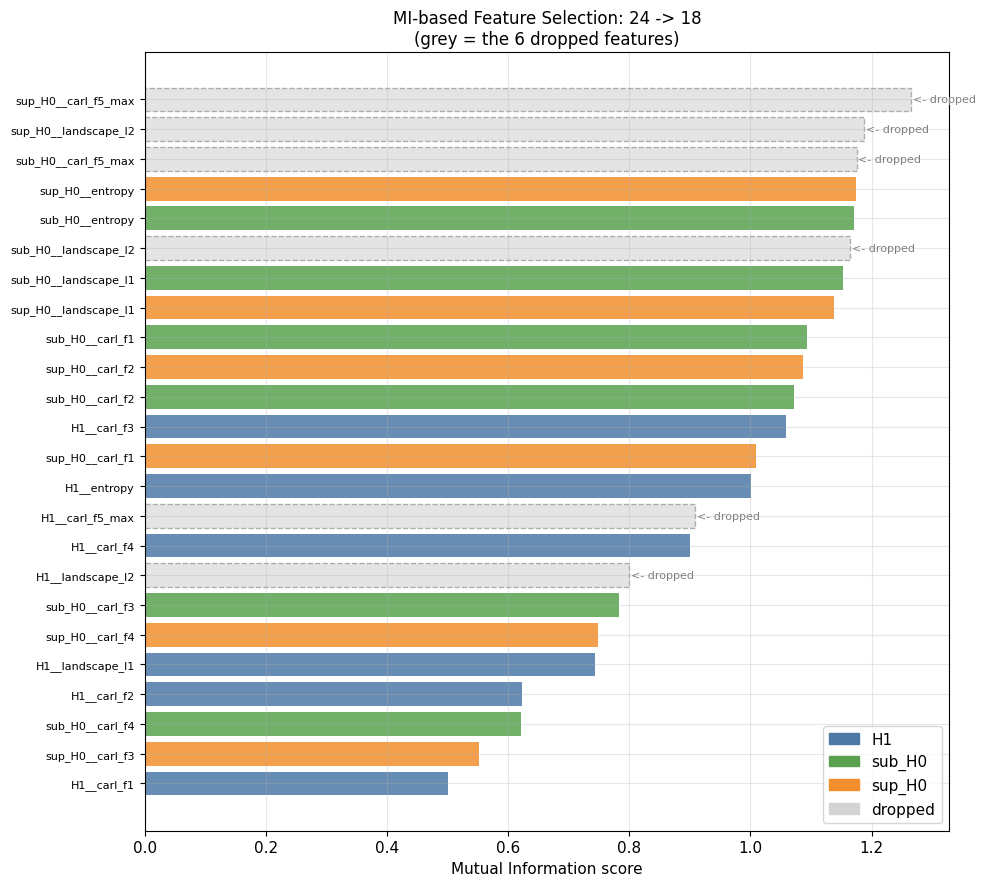

Highest MI: topo__sup_H0__carl_f5_max = 1.2648
Lowest MI (kept) : 0.5007


In [19]:
# ── MI score horizontal bar chart ───────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 9))

for i, (feat, score) in enumerate(mi_series.items()):
    is_dropped = feat in dropped_feats
    diagram = feat.split('__')[1] if '__' in feat else 'other'
    color = {'H1': '#4e79a7', 'sub_H0': '#59a14f', 'sup_H0': '#f28e2b'}.get(diagram, 'gray')
    if is_dropped:
        ax.barh(i, score, color='lightgray', edgecolor='gray', linestyle='--', alpha=0.6)
        ax.text(score + 0.003, i, '<- dropped', va='center', fontsize=8, color='gray')
    else:
        ax.barh(i, score, color=color, alpha=0.85)

ax.set_yticks(range(len(mi_series)))
ax.set_yticklabels([n.replace('topo__', '') for n in mi_series.index], fontsize=8)
ax.set_xlabel('Mutual Information score')
ax.set_title('MI-based Feature Selection: 24 -> 18\n(grey = the 6 dropped features)')

legend_patches = [
    mpatches.Patch(color='#4e79a7', label='H1'),
    mpatches.Patch(color='#59a14f', label='sub_H0'),
    mpatches.Patch(color='#f28e2b', label='sup_H0'),
    mpatches.Patch(color='lightgray', label='dropped'),
]
ax.legend(handles=legend_patches, loc='lower right')

plt.tight_layout()
plt.show()

print(f'Highest MI: {mi_series.idxmax()} = {mi_series.max():.4f}')
print(f'Lowest MI (kept) : {min(mi_series[mi_series.index.isin(selected_feats)]):.4f}')

## 11 - Cross-Class Comparison

Where are topological features strong and where are they weak?

- `sub_H0__carl_f3` is the most important feature in the hybrid model (#1 rank, 13.2% importance)
- **HIGH** cluster (`trend_shift`, `stationary`, `mean_shift`, `volatility`, ...): high persistence -> good separation
- **LOW** cluster (`stochastic_trend`, `point_anomaly`, `deterministic_trend`): low carl_f3 -> topology alone is weak

**Plot 3** answers two questions together:

| Panel | Question |
|-------|----------|
| sub_H0 barcode | "Is there a dominant structural break / barrier in the signal?" |
| H1 diagram | "Is there cyclic / periodic structure in the Takens embedding?" |

**Dominance ratio** = 1st bar / 2nd bar — high when one bar dominates, low when bars are uniformly spread.

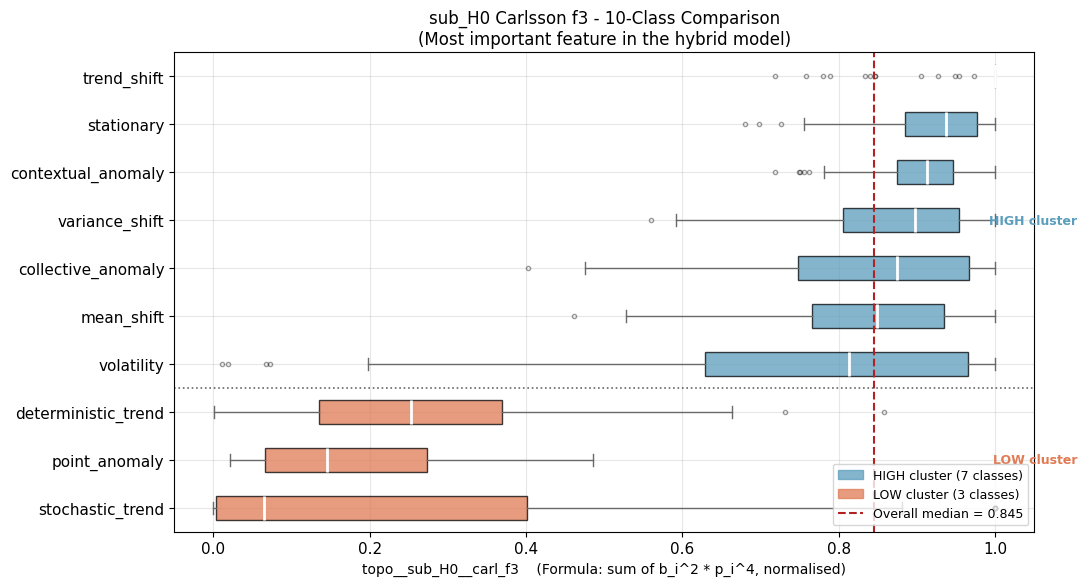

In [20]:
# ── Plot 1: topo__sub_H0__carl_f3 - horizontal boxplot, cluster-coloured ───────

feat_col   = 'topo__sub_H0__carl_f3'
all_merged = all_feat.merge(all_lbl[['series_id', 'primary_category']], on='series_id')

# Sort classes by ascending median (horizontal boxplot: low at bottom, high at top)
order = (all_merged.groupby('primary_category')[feat_col]
         .median().sort_values(ascending=True).index.tolist())

# Two natural clusters (from Section 10 summary)
HIGH_CLUSTER = {'trend_shift', 'stationary', 'contextual_anomaly',
                'variance_shift', 'collective_anomaly', 'mean_shift', 'volatility'}
LOW_CLUSTER  = {'stochastic_trend', 'point_anomaly', 'deterministic_trend'}

COLOR_HIGH = '#5b9dbd'   # blue - high-persistence classes
COLOR_LOW  = '#e07b54'   # orange - low-persistence classes

box_colors = [COLOR_LOW if c in LOW_CLUSTER else COLOR_HIGH for c in order]

data_by_class = [all_merged[all_merged['primary_category'] == cls][feat_col].values
                 for cls in order]

fig, ax = plt.subplots(figsize=(11, 6))

bp = ax.boxplot(data_by_class,
                vert=False,              # horizontal: class names on y-axis
                labels=order,
                patch_artist=True,
                notch=False,
                flierprops=dict(marker='o', markersize=3, alpha=0.4, linestyle='none'))

# Colour boxes by cluster
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Whiskers and median lines
for element in ('whiskers', 'caps', 'fliers'):
    for item in bp[element]:
        item.set_color('dimgray')
for median_line in bp['medians']:
    median_line.set(color='white', lw=2)

# Cluster boundary - horizontal dashed line between LOW and HIGH
low_count = sum(1 for c in order if c in LOW_CLUSTER)
ax.axhline(low_count + 0.5, color='black', lw=1.2, ls=':', alpha=0.6)

# Overall median - vertical red dashed line
overall_median = all_merged[feat_col].median()
ax.axvline(overall_median, color='firebrick', lw=1.5, ls='--',
           label=f'Overall median = {overall_median:.3f}')

# Cluster labels (right edge)
low_y  = (low_count + 1) / 2
high_y = low_count + (len(order) - low_count + 1) / 2
ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 1.05,
        low_y,  'LOW cluster',  va='center', ha='right',
        color=COLOR_LOW,  fontsize=9, fontweight='bold',
        transform=ax.get_yaxis_transform())
ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 1.05,
        high_y, 'HIGH cluster', va='center', ha='right',
        color=COLOR_HIGH, fontsize=9, fontweight='bold',
        transform=ax.get_yaxis_transform())

ax.set_xlabel('topo__sub_H0__carl_f3    (Formula: sum of b_i^2 * p_i^4, normalised)', fontsize=10)
ax.set_title('sub_H0 Carlsson f3 - 10-Class Comparison\n'
             '(Most important feature in the hybrid model)', fontsize=12)
ax.legend(loc='lower right', fontsize=9)

# Legend: cluster colours
legend_patches = [
    mpatches.Patch(color=COLOR_HIGH, alpha=0.75, label=f'HIGH cluster ({len(HIGH_CLUSTER)} classes)'),
    mpatches.Patch(color=COLOR_LOW,  alpha=0.75, label=f'LOW cluster ({len(LOW_CLUSTER)} classes)'),
]
ax.legend(handles=legend_patches +
          [plt.Line2D([0], [0], color='firebrick', ls='--', lw=1.5,
                      label=f'Overall median = {overall_median:.3f}')],
          loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

### How to read this plot?

**X-axis:** `topo__sub_H0__carl_f3` = $\sum b_i^2 \cdot p_i^4$ (normalised, in [0, 1]).  
For each series this is divided by the maximum of all 16 sublevel/superlevel features —
i.e. the value answers "how dominant is this feature in that series?"

**Boxes:** Distribution across the 100 series of each class.  
- Box left edge: 1st quartile (Q1)  
- White line inside: median  
- Box right edge: 3rd quartile (Q3)  
- Whiskers: IQR x 1.5 limit; points beyond are outliers

**The horizontal dashed separator between the two clusters:**

| Cluster | Classes | Why high / low? |
|---------|---------|------------------|
| HIGH (>= 0.80) | trend_shift, stationary, mean_shift, ... | Series contain **bars born at high levels with long persistence** (b large, p large -> b^2 * p^4 large) |
| LOW  (<= 0.25) | stochastic_trend, point_anomaly, deterministic_trend | carl_f3 is **not** the dominant feature for these series — others are larger |

**Why is `trend_shift` median exactly 1.0?**  
Normalisation: each series divides its 16 features by their max -> the max becomes 1.0.
For `trend_shift` series, **carl_f3 is already the largest feature**, so the median is ~ 1.0.

**Why is the `stochastic_trend` box wide?**  
Random walk: structure varies dramatically between series — sometimes it looks like trend_shift,
sometimes like flat noise -> large IQR.

**Why is `point_anomaly` low?**  
In the sub_H0 barrier bar, **birth ~ noise level** (b ~ 0).  
The $b^2$ factor in the formula crushes the large persistence:  
the bar is long but b ~ 0 -> $b^2 \cdot p^4$ ~ 0.

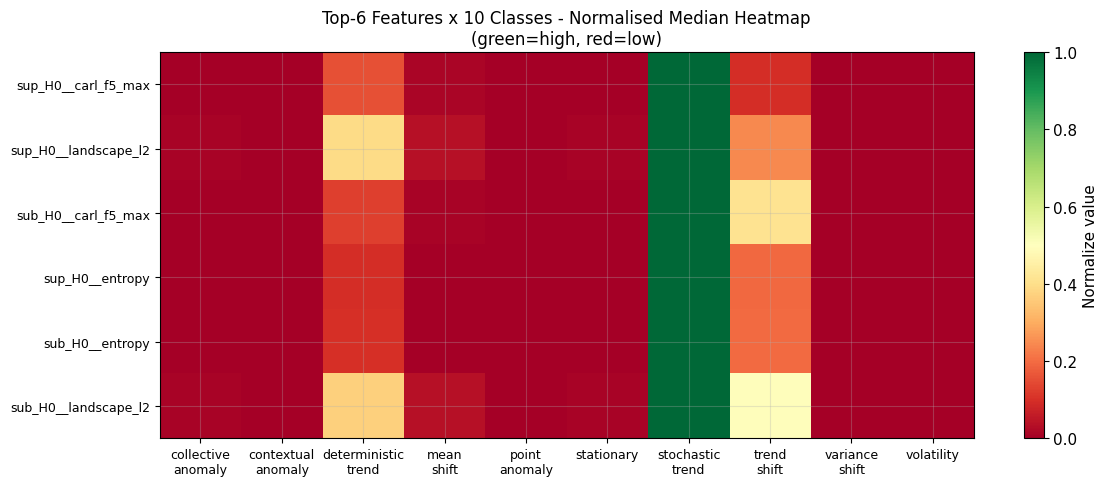

In [21]:
# ── Plot 2: Top-6 features x 10 classes heatmap ───────────────────────────────

top6 = mi_series.nlargest(6).index.tolist()  # high to low (most important on top)

# Normalised median per class
pivot = (all_merged.groupby('primary_category')[top6]
         .median()
         .apply(lambda col: (col - col.min()) / (col.max() - col.min() + 1e-9)))

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot.values.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.index)))
ax.set_xticklabels([c.replace('_', '\n') for c in pivot.index], fontsize=9)
ax.set_yticks(range(len(top6)))
ax.set_yticklabels([n.replace('topo__', '') for n in top6], fontsize=9)
ax.set_title('Top-6 Features x 10 Classes - Normalised Median Heatmap\n'
             '(green=high, red=low)')
plt.colorbar(im, ax=ax, label='Normalize value')
plt.tight_layout()
plt.show()

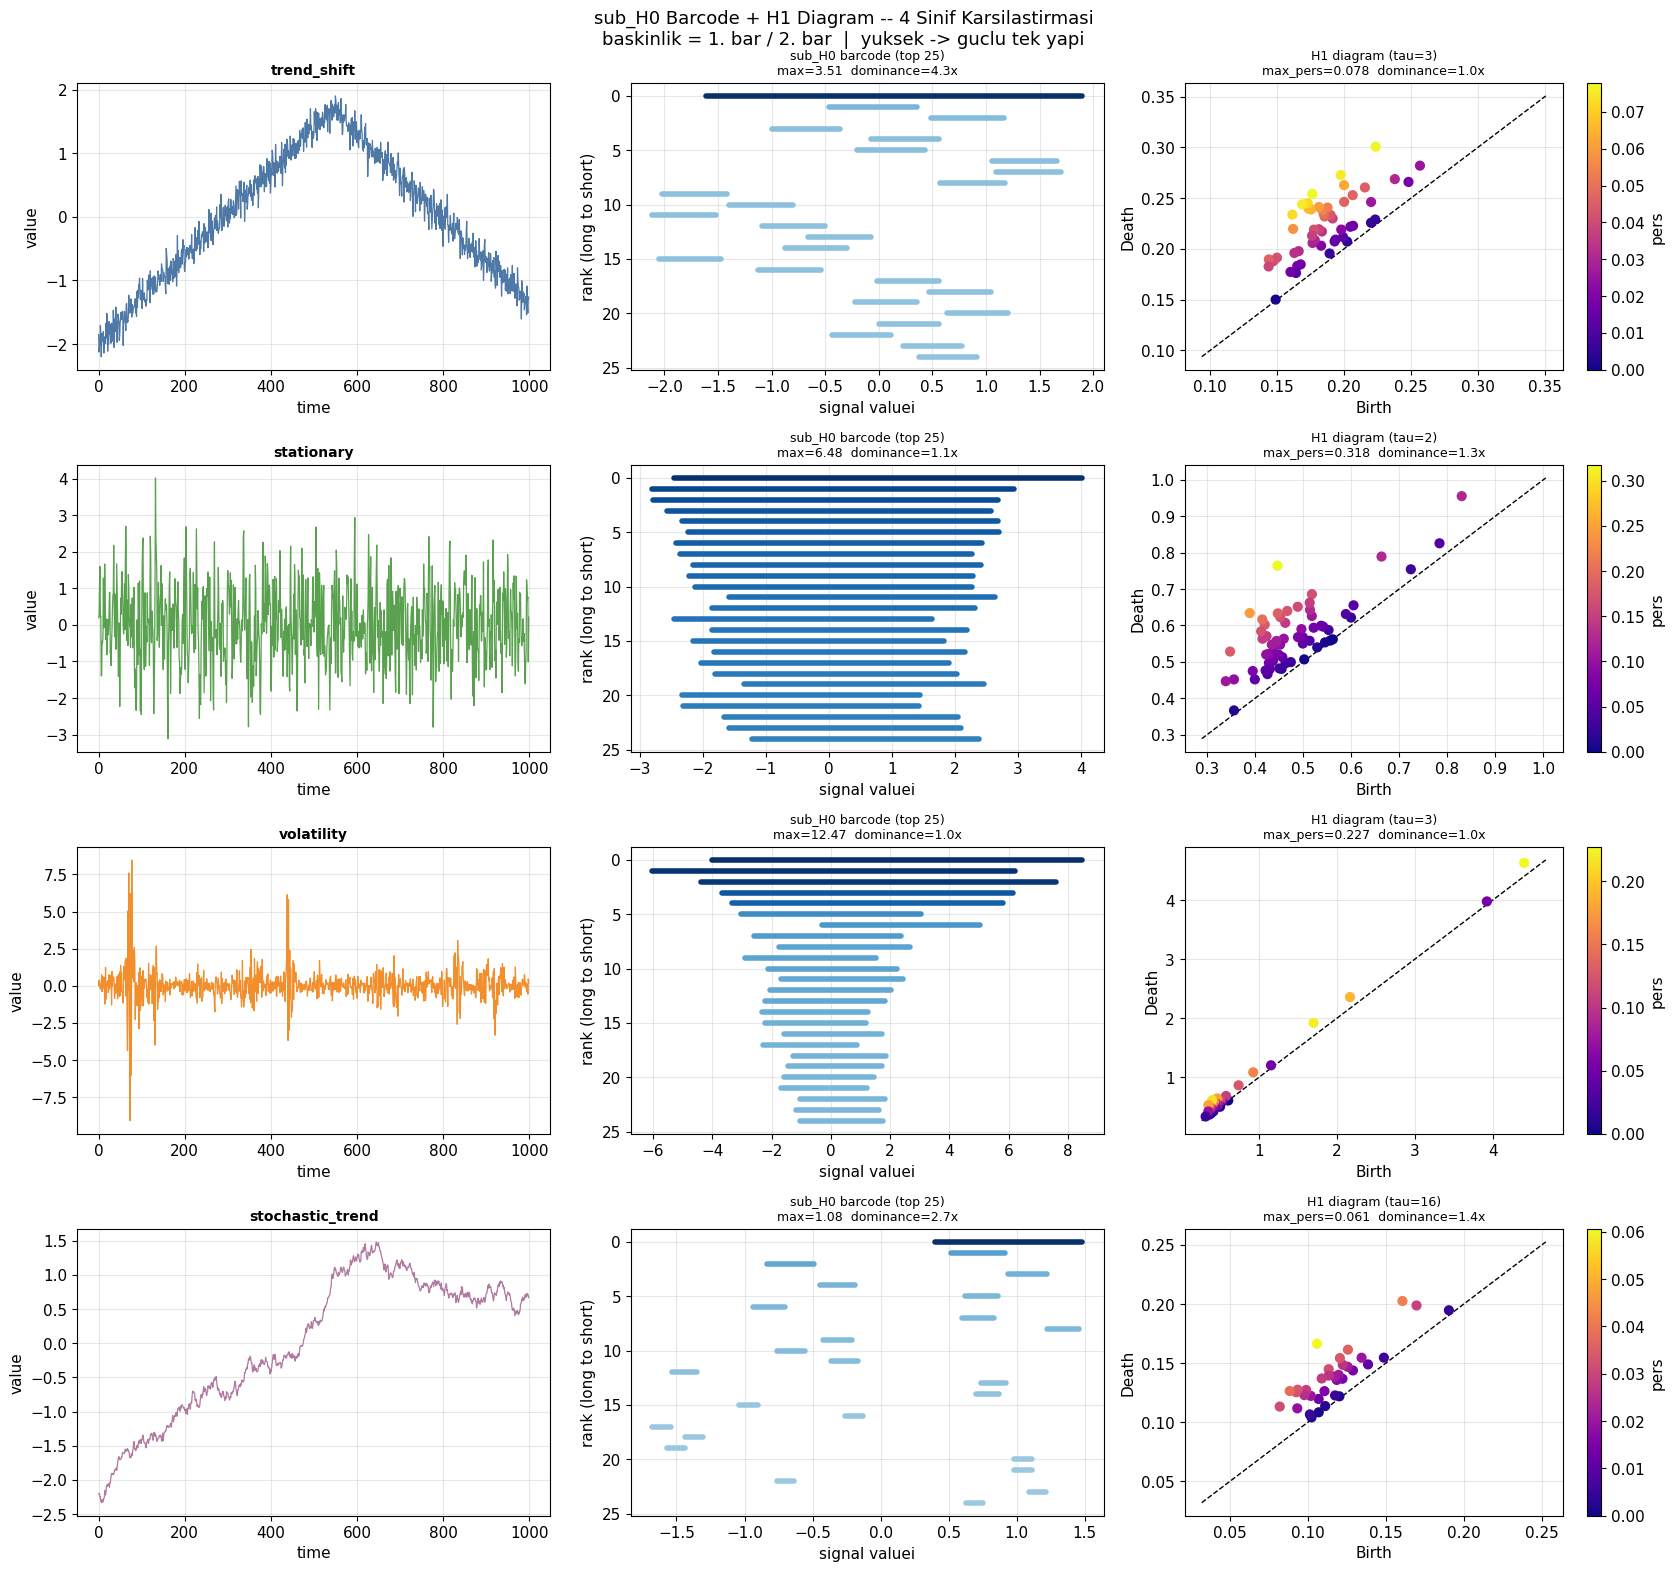

sub_H0 dominance summary:
  trend_shift             max_pers=3.508  dominance=4.3x
  stationary              max_pers=6.482  dominance=1.1x
  volatility              max_pers=12.473  dominance=1.0x
  stochastic_trend        max_pers=1.080  dominance=2.7x


In [22]:
# -- Gorsel 3: 4 sinif x (signal | sub_H0 barcode | H1 diagram) --
#
# sub_H0 barcode: sorted persistence bars - clearest view of the '1 dominant bar' pattern
# H1 diagram   : Is there cyclic structure via Takens embedding?

COMPARE_CLASSES = ['trend_shift', 'stationary', 'volatility', 'stochastic_trend']

fig, axes = plt.subplots(4, 3, figsize=(17, 16))

for row, cls in enumerate(COMPARE_CLASSES):
    ts = example_series[cls].astype(float)

    # Column 0: Signal
    axes[row, 0].plot(ts, lw=0.9,
                      color=['#4e79a7','#59a14f','#f28e2b','#b07aa1'][row])
    axes[row, 0].set_title(cls, fontsize=10, fontweight='bold')
    axes[row, 0].set_xlabel('time'); axes[row, 0].set_ylabel('value')

    # Column 1: sub_H0 sorted barcode
    sub_diag = _sub(ts)
    max_pers_s = 0.0
    dom_ratio  = 'N/A'
    if len(sub_diag):
        pers_s   = sub_diag[:, 1] - sub_diag[:, 0]
        pos_mask = pers_s > 1e-6
        pers_pos = pers_s[pos_mask]
        sub_pos  = sub_diag[pos_mask]
        if len(pers_pos):
            top_n   = min(25, len(pers_pos))
            idx_top = np.argsort(-pers_pos)[:top_n]
            cmap_s  = get_cmap('Blues')
            nrm_s   = Normalize(vmin=0, vmax=pers_pos.max())
            for rank, i in enumerate(idx_top):
                axes[row, 1].plot([sub_pos[i, 0], sub_pos[i, 1]],
                                  [rank, rank], lw=4, solid_capstyle='round',
                                  color=cmap_s(0.3 + 0.7 * nrm_s(pers_pos[i])))
            sorted_p  = np.sort(pers_pos)[::-1]
            max_pers_s = sorted_p[0]
            dom_ratio  = '{:.1f}x'.format(sorted_p[0] / sorted_p[1]) if len(sorted_p) > 1 else 'inf'
    axes[row, 1].set_title(
        'sub_H0 barcode (top {})\nmax={:.2f}  dominance={}'.format(top_n if len(sub_diag) else 0, max_pers_s, dom_ratio),
        fontsize=9)
    axes[row, 1].invert_yaxis()
    axes[row, 1].set_xlabel('signal valuei')
    axes[row, 1].set_ylabel('rank (long to short)')

    # Column 2: H1 - Takens embedding + Ripser
    try:
        tau_h1 = estimate_delay_mi(ts, max_lag=50)
        tau_h1 = max(1, min(tau_h1, len(ts) // 4))
        cloud  = np.column_stack([ts[:-tau_h1], ts[tau_h1:]])
        n_perm = min(150, len(cloud) - 1)
        res_h1 = ripser(cloud, maxdim=1, n_perm=n_perm)
        dgm_h1 = res_h1['dgms'][1]
        finite = dgm_h1[np.isfinite(dgm_h1[:, 1])]
        if len(finite):
            pers_h1 = finite[:, 1] - finite[:, 0]
            sc = axes[row, 2].scatter(
                finite[:, 0], finite[:, 1],
                c=pers_h1, cmap='plasma', s=40,
                vmin=0, vmax=pers_h1.max(), zorder=3)
            lo = finite.min() - 0.05; hi = finite.max() + 0.05
            axes[row, 2].plot([lo, hi], [lo, hi], 'k--', lw=1)
            plt.colorbar(sc, ax=axes[row, 2], label='pers')
            top_h1 = np.sort(pers_h1)[::-1]
            dom_h1 = '{:.1f}x'.format(top_h1[0] / top_h1[1]) if len(top_h1) > 1 else 'inf'
            axes[row, 2].set_title(
                'H1 diagram (tau={})\nmax_pers={:.3f}  dominance={}'.format(tau_h1, top_h1[0], dom_h1),
                fontsize=9)
        else:
            axes[row, 2].set_title('H1 (tau={})\n(no finite bars)'.format(tau_h1), fontsize=9)
    except Exception as e:
        axes[row, 2].set_title('H1 - error: {}'.format(e), fontsize=8)
    axes[row, 2].set_xlabel('Birth'); axes[row, 2].set_ylabel('Death')

fig.suptitle(
    'sub_H0 Barcode + H1 Diagram -- 4 Sinif Karsilastirmasi\n'
    'baskinlik = 1. bar / 2. bar  |  yuksek -> guclu tek yapi',
    fontsize=13)
plt.tight_layout()
plt.show()

print('sub_H0 dominance summary:')
for cls in COMPARE_CLASSES:
    ts   = example_series[cls].astype(float)
    diag = _sub(ts)
    p    = np.sort(diag[:, 1] - diag[:, 0])[::-1]
    p    = p[p > 1e-6]
    dom  = '{:.1f}x'.format(p[0] / p[1]) if len(p) > 1 else 'inf'
    print('  {:22s}  max_pers={:.3f}  dominance={}'.format(cls, p[0], dom))

### How to read this grid - Key Takeaway

**A striking contrast:**

| Class | sub_H0 max_pers | sub_H0 dominance |
|-------|-----------------|-------------------|
| `trend_shift` | 3.51 | **4.3x** (1 dominant bar) |
| `stationary` | **6.48** | 1.1x (equal bars) |
| `volatility` | **12.47** | 1.0x (equal bars) |
| `stochastic_trend` | 1.08 | 2.7x (moderate dominance) |

> **"Longest bar" does not give class separation - dominance does.**
>
> `volatility` series have very high amplitude oscillations, hence very high max_pers (12.47),
> but all bars are of similar length -> the information is not concentrated in any single
> structure. In contrast, `trend_shift` produces a small number of dominant bars -> the
> class signature is sharper.

**H1 panel:** None of the classes show very prominent H1 structure (none are truly periodic).
H1 features play a **supporting role** in the Part 2 model — small differences across
the 24-D vector still combine into class-specific patterns.

**A practical interpretation rule (for understanding the model):**
1. Is `sub_H0__carl_f3` high? -> HIGH cluster in the boxplot of Section 11
2. Is `sub_H0` entropy low? -> Few dominant bars (`trend_shift`, `point_anomaly` type)
3. Is H1 max_pers meaningful? -> Cyclic structure (rare, but a strong signal when present)

In [23]:
# ── Summary table: per-class discriminative power of topology features ────────────────────

print('Per-class sub_H0__carl_f3 medians (large -> easy class separation):')
print('=' * 55)
medians = (all_merged.groupby('primary_category')['topo__sub_H0__carl_f3']
           .median().sort_values(ascending=False))
max_val = medians.max()
for cls, val in medians.items():
    bar_len = max(0, int(val / (max_val + 1e-9) * 30))
    indicator = '▓' * bar_len + '░' * (30 - bar_len)
    print(f'{cls:25s} {val:8.4f}  {indicator}')

print()
print('Advantage of topological features:')
print('  * Structural changes such as trend_shift, mean_shift -> high persistence -> good separation')
print('  * 18 features give RandomForest 86.5% accuracy (vs 91.4% with 100 TSFresh features)')
print('  * Ratio: 5.3x more efficient (accuracy per feature)')


Per-class sub_H0__carl_f3 medians (large -> easy class separation):
trend_shift                 1.0000  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░
stationary                  0.9372  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░
contextual_anomaly          0.9129  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░
variance_shift              0.8976  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░░
collective_anomaly          0.8740  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░░
mean_shift                  0.8488  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░░░
volatility                  0.8124  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░░░░
deterministic_trend         0.2533  ▓▓▓▓▓▓▓░░░░░░░░░░░░░░░░░░░░░░░
point_anomaly               0.1454  ▓▓▓▓░░░░░░░░░░░░░░░░░░░░░░░░░░
stochastic_trend            0.0645  ▓░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

Advantage of topological features:
  * Structural changes such as trend_shift, mean_shift -> high persistence -> good separation
  * 18 features give RandomForest 86.5% accuracy (vs 91.4% with 100 TSFresh features)
  * Ratio: 5.3x more efficient (accuracy per f

---
## Summary

| Concept | Section | Key idea |
|---------|---------|----------|
| Sublevel H0 | 1-2 | Valleys -> bars; long = meaningful |
| Spike detection | 3 | A spike creates a barrier bar (sub_H0); in sup_H0 it is the essential class |
| Takens + H1 | 4 | Cyclicity -> circle -> 1 long H1 bar |
| Vectorisation | 5 | 8 numbers: Carlsson x 5 + entropy + L1 + L2 |
| `topology_extraction.py` | 6-8 | CombinedExtractor -> 24 features |
| Batch pipeline | 9 | 1000 series, Parallel, features.parquet |
| MI + redundancy pruning | 10 | 24 -> 18 (carl_f5_max + landscape_l2 dropped per diagram) |
| Class analysis | 11 | Strong for trend_shift; weak for stationary |

### Essential Class Note
> The **global maximum** of a signal is the "essential class" of superlevel filtration —  
> it lives forever and is **invisible** in the finite barcode.  
> That is why isolated spikes are caught by **sub_H0**:  
> the spike places a barrier and the death value of neighbouring valleys = spike height.

**Code references:**
- `02-preprocessing/topology_extraction.py` — all extraction code
- `02-preprocessing/feature_selection.py` — MI-based selection
- `03-models/` — classification models